# Forest Species Classification — Multi-Level Model Comparison
Compares **Random Forest** and **MLP (regularized)** across:
- 3 classification **levels** (1 = coarse, 3 = fine-grained species)
- 4 feature sets: raw · VI-stats · VI-stats+trad-aug · VI-stats+spec-aug
- 2 **augmentation strategies** (applied to VI-stats only): traditional (geometric) · spectral (band dropout)
- Models are reloaded from disk if already saved — no redundant retraining

**Strategy:** (3 levels and 4 feature sets) × 2 models = 12 runs total:  
- **Phase 1 (8 runs):** Level-3 only × 4 feature sets × 2 models → pick best feature set  
- **Phase 2 (4 runs):** 3 levels × best feature set × 2 models

---
## 1  Imports & Config

In [1]:
import os, warnings
import numpy as np
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score, average_precision_score
)
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATASET_DIR = "C:\\Users\\uceda\\Documents\\uni\\master\\ENLIGHT\\course\\data\\dataset\\s2\\200m"
TRAIN_LST   = "../data/train_filenames.lst"
TEST_LST    = "../data/test_filenames.lst"
CACHE_DIR   = "../data/cache"
MODEL_DIR   = "../data/models"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Patch geometry ─────────────────────────────────────────────────────────────
MAX_H, MAX_W = 21, 21

# ── Training hyper-params ──────────────────────────────────────────────────────
EPOCHS     = 150
BATCH_SIZE = 32
LR_MIN     = 5e-5
LR_MAX     = 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


---
## 2  Taxonomy — species → level mappings

In [2]:
# Level-3 species (20 classes, same order as filenames / original label indices)
species_list = [
    'Abies_alba',           # 0  → silver fir
    'Acer_pseudoplatanus',  # 1  → sycamore maple
    'Alnus_spec',           # 2  → alder
    'Betula_spec',          # 3  → birch
    'Cleared',              # 4  → cleared
    'Fagus_sylvatica',      # 5  → european beech
    'Fraxinus_excelsior',   # 6  → european ash
    'Larix_decidua',        # 7  → european larch
    'Larix_kaempferi',      # 8  → japanese larch
    'Picea_abies',          # 9  → norway spruce
    'Pinus_nigra',          # 10 → black pine
    'Pinus_strobus',        # 11 → weymouth pine
    'Pinus_sylvestris',     # 12 → scots pine
    'Populus_spec',         # 13 → poplar
    'Prunus_spec',          # 14 → cherry
    'Pseudotsuga_menziesii',# 15 → douglas fir
    'Quercus_petraea',      # 16 → sessile oak
    'Quercus_robur',        # 17 → english oak
    'Quercus_rubra',        # 18 → red oak
    'Tilia_spec',           # 19 → linden
]
NUM_CLASSES_L3 = len(species_list)  # 20

# ── Level-2 mapping  (species_idx → level2_label_string) ──────────────────────
# From the hierarchy image:
#   oak            : sessile oak, english oak, red oak           (16,17,18)
#   beech          : european beech                              (5)
#   long-lived dec : sycamore maple, european ash, linden, cherry(1,6,19,14)
#   short-lived dec: alder, poplar, birch                        (2,13,3)
#   fir            : silver fir                                  (0)        
#   spruce         : norway spruce                               (9)        
#   douglas fir    : douglas fir                                 (15)
#   pine           : scots pine, black pine, weymouth pine       (12,10,11)
#   larch          : european larch, japanese larch              (7,8)
#   cleared        : cleared                                     (4)
LEVEL2_MAP = {
    0:  'fir',                    # Abies alba — silver fir
    1:  'long_lived_deciduous',
    2:  'short_lived_deciduous',
    3:  'short_lived_deciduous',
    4:  'cleared',
    5:  'beech',
    6:  'long_lived_deciduous',
    7:  'larch',
    8:  'larch',
    9:  'spruce',                 # Picea abies — norway spruce
    10: 'pine',
    11: 'pine',
    12: 'pine',
    13: 'short_lived_deciduous',
    14: 'long_lived_deciduous',
    15: 'douglas_fir',
    16: 'oak',
    17: 'oak',
    18: 'oak',
    19: 'long_lived_deciduous',
}

# ── Level-1 mapping  (species_idx → level1_label_string) ──────────────────────
#   broadleaf  : all deciduous + oak + beech                    (1-3,5,6,13,14,16-19)
#   needleleaf : spruce, fir, douglas fir, pine, larch          (0,7-12,15)
#   cleared    : cleared                                        (4)
LEVEL1_MAP = {
    0:  'needleleaf',
    1:  'broadleaf',
    2:  'broadleaf',
    3:  'broadleaf',
    4:  'cleared',
    5:  'broadleaf',
    6:  'broadleaf',
    7:  'needleleaf',
    8:  'needleleaf',
    9:  'needleleaf',
    10: 'needleleaf',
    11: 'needleleaf',
    12: 'needleleaf',
    13: 'broadleaf',
    14: 'broadleaf',
    15: 'needleleaf',
    16: 'broadleaf',
    17: 'broadleaf',
    18: 'broadleaf',
    19: 'broadleaf',
}

def build_level_labels(y_l3: np.ndarray, level_map: dict) -> tuple:
    """Convert integer level-3 labels → integer labels for a coarser level.
    Returns (y_new, class_names) where class_names is sorted alphabetically."""
    unique_names = sorted(set(level_map.values()))
    name2idx     = {n: i for i, n in enumerate(unique_names)}
    y_new = np.array([name2idx[level_map[c]] for c in y_l3], dtype=np.int64)
    return y_new, unique_names

print('Taxonomy loaded.')
print(f'  Level-3 classes : {NUM_CLASSES_L3}' 
      f' ({species_list})')
print(f'  Level-2 classes : {len(set(LEVEL2_MAP.values()))}  '
      f'({sorted(set(LEVEL2_MAP.values()))})')
print(f'  Level-1 classes : {len(set(LEVEL1_MAP.values()))}' 
      f' ({sorted(set(LEVEL1_MAP.values()))})')

Taxonomy loaded.
  Level-3 classes : 20 (['Abies_alba', 'Acer_pseudoplatanus', 'Alnus_spec', 'Betula_spec', 'Cleared', 'Fagus_sylvatica', 'Fraxinus_excelsior', 'Larix_decidua', 'Larix_kaempferi', 'Picea_abies', 'Pinus_nigra', 'Pinus_strobus', 'Pinus_sylvestris', 'Populus_spec', 'Prunus_spec', 'Pseudotsuga_menziesii', 'Quercus_petraea', 'Quercus_robur', 'Quercus_rubra', 'Tilia_spec'])
  Level-2 classes : 10  (['beech', 'cleared', 'douglas_fir', 'fir', 'larch', 'long_lived_deciduous', 'oak', 'pine', 'short_lived_deciduous', 'spruce'])
  Level-1 classes : 3 (['broadleaf', 'cleared', 'needleleaf'])


---
## 3  I/O helpers — loading, caching, vegetation indices

In [3]:
# ── Filename → label index ─────────────────────────────────────────────────────
def filename_to_idx(filename: str) -> int:
    for i, species in enumerate(species_list):
        if species in filename:
            return i
    return 0

# ── Load one .tif as (12, H, W), zero-pad to (12, MAX_H, MAX_W) ──────────────
def load_tif_raw(filename: str) -> np.ndarray:
    """Returns float32 array shaped (12, MAX_H, MAX_W)."""
    path = os.path.join(DATASET_DIR, filename)
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)        # (12, H, W)
    pad_h = MAX_H - img.shape[1]
    pad_w = MAX_W - img.shape[2]
    img = np.pad(img, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
    return img                                      # (12, 21, 21)

# ── Vegetation indices ────────────────────────────────────────────────────────
VI_NAMES = ['NDVI', 'EVI', 'NDRE', 'PSRI', 'NDMI', 'SRWI', 'GLI']  # 7 selected

def compute_vi_maps(img: np.ndarray) -> np.ndarray:
    """img: (12, H, W) → returns (7, H, W) for the 7 selected VIs."""
    B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12 = img
    eps = 1e-8
    ndvi = (B8 - B4)  / (B8 + B4  + eps)
    evi  = 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1 + eps)
    ndre = (B8 - B7)  / (B8 + B7  + eps)
    psri = (B4 - B3)  / (B8       + eps)
    ndmi = (B8 - B11) / (B8 + B11 + eps)
    srwi = (B11 - B8) / (B11 + B8 + eps)
    gli  = (2*B3 - B2 - B4) / (2*B3 + B2 + B4 + eps)
    return np.stack([ndvi, evi, ndre, psri, ndmi, srwi, gli], axis=0)  # (7,H,W)

def compute_vi_stats(img: np.ndarray) -> np.ndarray:
    """img: (12, H, W) → 7 VIs × 4 stats (mean/std/min/max) = 28 features."""
    vi = compute_vi_maps(img)  # (7, H, W)
    feats = []
    for i in range(7):
        feats += [vi[i].mean(), vi[i].std(), vi[i].min(), vi[i].max()]
    return np.array(feats, dtype=np.float32)  # (28,)

# ── Build / load cached split ─────────────────────────────────────────────────
def build_split(filenames: list, split_name: str):
    """Builds three feature matrices and a shared label vector.
    Caches all to CACHE_DIR as .npy.
    Returns:
        X_raw   (N, 12*21*21=5292)  – flattened bands
        X_idx   (N, 28)             – VI stats
        X_3d    (N, 12, 21, 21)     – 3-D patches (needed for augmentation)
        y       (N,)                – level-3 integer labels
    """
    X_raw_path = os.path.join(CACHE_DIR, f'X_raw_{split_name}.npy')
    X_idx_path = os.path.join(CACHE_DIR, f'X_idx_{split_name}.npy')
    X_3d_path  = os.path.join(CACHE_DIR, f'X_3d_{split_name}.npy')
    y_path     = os.path.join(CACHE_DIR, f'y_{split_name}.npy')

    if all(os.path.exists(p) for p in [X_raw_path, X_idx_path, X_3d_path, y_path]):
        print(f'Loading cached {split_name}...')
        return (
            np.load(X_raw_path),
            np.load(X_idx_path),
            np.load(X_3d_path),
            np.load(y_path),
        )

    print(f'Building {split_name} from .tif files...')
    X_raw_list, X_idx_list, X_3d_list, y_list = [], [], [], []
    for i, fn in enumerate(filenames):
        if i % 1000 == 0:
            print(f'  {i}/{len(filenames)}')
        img = load_tif_raw(fn)               # (12, 21, 21)
        X_raw_list.append(img.flatten())     # (5292,)
        X_idx_list.append(compute_vi_stats(img))  # (28,)
        X_3d_list.append(img)               # (12, 21, 21)
        y_list.append(filename_to_idx(fn))

    X_raw = np.array(X_raw_list, dtype=np.float32)
    X_idx = np.array(X_idx_list, dtype=np.float32)
    X_3d  = np.array(X_3d_list,  dtype=np.float32)
    y     = np.array(y_list,     dtype=np.int64)

    np.save(X_raw_path, X_raw)
    np.save(X_idx_path, X_idx)
    np.save(X_3d_path,  X_3d)
    np.save(y_path,     y)
    print(f'  Saved to {CACHE_DIR}')
    return X_raw, X_idx, X_3d, y

print('I/O helpers defined.')

I/O helpers defined.


---
## 4  Augmentation helpers

In [4]:
# ── Traditional augmentation (geometric) ──────────────────────────────────────
# For nadir remote sensing a canopy patch has no preferred orientation:
# 4 rotations × 2 flips = ×8 factor (original kept, 7 new variants per sample).

def geometric_augment(X_3d: np.ndarray, y: np.ndarray):
    """X_3d: (N, C, H, W).  Returns augmented (N*8, C, H, W) and labels (N*8,)."""
    variants = []
    for k in range(4):
        rot = np.rot90(X_3d, k=k, axes=(2, 3))
        variants.append(rot)
        variants.append(np.flip(rot, axis=3).copy())
    X_aug = np.concatenate(variants, axis=0)
    y_aug = np.tile(y, 8)
    return X_aug.astype(np.float32), y_aug

def flatten_raw(X_3d: np.ndarray) -> np.ndarray:
    """(N, C, H, W) → (N, C*H*W)"""
    return X_3d.reshape(X_3d.shape[0], -1)

def extract_vi_stats_batch(X_3d: np.ndarray) -> np.ndarray:
    """(N, 12, H, W) → (N, 28)"""
    return np.array([compute_vi_stats(x) for x in X_3d], dtype=np.float32)

# ── Spectral augmentation (band dropout) ──────────────────────────────────────
# Drops random bands from each sample, inspired by Brüel-Gabrielsson et al. 2025
# (Deep Augmentation) which applies dropout to targeted layers/axes, and
# Pirinen et al. 2025 (Grazing) which drops the *time* axis per batch.
# Here we drop the *spectrum* axis — same principle, applied to a different axis.
#
# KEY DESIGN DECISIONS (consistent with both papers):
#   • B08 (NIR, index 7) is NEVER dropped — it enters NDVI, EVI, NDRE, PSRI,
#     NDMI, SRWI simultaneously; dropping it corrupts most VI features at once.
#   • p_drop=0.35 matches the per-step dropout rate in Pirinen et al. 2025.
#   • For the MLP, dropout is applied DYNAMICALLY per batch (fresh masks each
#     epoch), following the spirit of both papers. The static pool below is
#     used only for RF, which cannot do online augmentation.
#   • Partial-batch augmentation (50% of samples per batch) follows the
#     Deep Augmentation paper (§3 "Partial Batch Sampling"), which found that
#     augmenting only half the batch improves training stability.

NIR_BAND_IDX = 7  # B08 — always protected

def spectral_band_dropout(X_3d: np.ndarray, y: np.ndarray,
                           n_copies: int = 7, p_drop: float = 0.35,
                           seed: int | None = None) -> tuple:
    """Build n_copies static band-dropout variants (used for RF static pool).

    Each copy uses a distinct seed for reproducible but unique dropout patterns.
    B08 (NIR, index NIR_BAND_IDX) is always preserved.
    Returns (N*(n_copies+1), C, H, W) with originals as copy 0.
    """
    N, C, H, W = X_3d.shape
    copies = [X_3d]
    for i in range(n_copies):
        rng  = np.random.default_rng(seed if seed is not None else i)
        mask = rng.random((N, C, 1, 1)) > p_drop
        mask[:, NIR_BAND_IDX, :, :] = True          # protect NIR
        copies.append((X_3d * mask).astype(np.float32))
    X_aug = np.concatenate(copies, axis=0)
    y_aug = np.tile(y, n_copies + 1)
    return X_aug.astype(np.float32), y_aug

print('Augmentation helpers defined.')
print(f'  NIR band (B08) protected at index {NIR_BAND_IDX}.')


Augmentation helpers defined.
  NIR band (B08) protected at index 7.


---
## 5  Load data & build all feature sets

In [5]:
with open(TRAIN_LST) as f:
    train_filenames = f.read().splitlines()
with open(TEST_LST) as f:
    test_filenames = f.read().splitlines()
print(f'Train: {len(train_filenames)} | Test: {len(test_filenames)}')

Train: 45337 | Test: 5044


In [6]:
# ── 5.1  Load base arrays (cached after first run) ────────────────────────────
X_raw_train, X_idx_train, X_3d_train, y_l3_train = build_split(train_filenames, 'train')
X_raw_test,  X_idx_test,  X_3d_test,  y_l3_test  = build_split(test_filenames,  'test')

print(f'X_raw_train : {X_raw_train.shape}  X_idx_train : {X_idx_train.shape}')
print(f'X_3d_train  : {X_3d_train.shape}')
print(f'y_l3_train  : {y_l3_train.shape}  (range {y_l3_train.min()}–{y_l3_train.max()})')

Loading cached train...


Loading cached test...
X_raw_train : (45337, 5292)  X_idx_train : (45337, 28)
X_3d_train  : (45337, 12, 21, 21)
y_l3_train  : (45337,)  (range 0–19)


In [7]:
# ── 5.2  Build augmented VI-stats in chunks (avoids large 3-D intermediate) ──
# The full augmented 3-D array (N×8, 12, 21, 21) is ~7 GB — never materialised.
# We stream each variant, compute VI stats on the fly, and concatenate the
# compact (N, 28) results.  The static pool is used for RF; the MLP receives
# dynamic per-batch dropout instead (see SpectralDropoutDataset in §7).

X_idx_trad_path = os.path.join(CACHE_DIR, 'X_idx_trad_train.npy')
X_idx_spec_path = os.path.join(CACHE_DIR, 'X_idx_spec_train.npy')
y_trad_path     = os.path.join(CACHE_DIR, 'y_trad_train.npy')
y_spec_path     = os.path.join(CACHE_DIR, 'y_spec_train.npy')

if all(os.path.exists(p) for p in [X_idx_trad_path, X_idx_spec_path, y_trad_path, y_spec_path]):
    print('Cached augmented arrays found — skipping.')
    y_trad_train = np.load(y_trad_path)
    y_spec_train = np.load(y_spec_path)
else:
    # ── Traditional (geometric ×8) ────────────────────────────────────────────
    print('Computing VI stats for traditional augmented set...')
    idx_trad_parts = []
    for k in range(4):
        for do_flip in [False, True]:
            rot     = np.rot90(X_3d_train, k=k, axes=(2, 3))
            variant = np.flip(rot, axis=3).copy() if do_flip else rot.copy()
            idx_trad_parts.append(extract_vi_stats_batch(variant))
            print(f'  rotation {k*90}° flip={do_flip} → done')
    X_idx_trad_train = np.concatenate(idx_trad_parts, axis=0)   # (N*8, 28)
    y_trad_train     = np.tile(y_l3_train, 8)

    # ── Spectral (band-dropout ×8, NIR-protected) ─────────────────────────────
    # spectral_band_dropout uses seed=i for each copy → 7 distinct patterns.
    print('Computing VI stats for spectral augmented set (NIR-protected)...')
    X_3d_aug, _     = spectral_band_dropout(X_3d_train, y_l3_train,
                                             n_copies=7, p_drop=0.35)
    N = len(X_3d_train)
    idx_spec_parts  = [extract_vi_stats_batch(X_3d_aug[i*N:(i+1)*N])
                       for i in range(8)]
    X_idx_spec_train = np.concatenate(idx_spec_parts, axis=0)   # (N*8, 28)
    y_spec_train     = np.tile(y_l3_train, 8)
    print(f'  spec aug shape: {X_idx_spec_train.shape}')
    print('Done.')


Cached augmented arrays found — skipping.


In [8]:
# ── 5.3  Cache / reload augmented VI-stats arrays ────────────────────────────
X_idx_trad_path = os.path.join(CACHE_DIR, 'X_idx_trad_train.npy')
X_idx_spec_path = os.path.join(CACHE_DIR, 'X_idx_spec_train.npy')
y_trad_path     = os.path.join(CACHE_DIR, 'y_trad_train.npy')
y_spec_path     = os.path.join(CACHE_DIR, 'y_spec_train.npy')

if all(os.path.exists(p) for p in [X_idx_trad_path, X_idx_spec_path, y_trad_path, y_spec_path]):
    print('Loading cached augmented VI-stats arrays...')
    X_idx_trad_train = np.load(X_idx_trad_path)
    X_idx_spec_train = np.load(X_idx_spec_path)
    y_trad_train     = np.load(y_trad_path)
    y_spec_train     = np.load(y_spec_path)
else:
    print('Saving augmented VI-stats arrays to cache...')
    np.save(X_idx_trad_path, X_idx_trad_train)
    np.save(X_idx_spec_path, X_idx_spec_train)
    np.save(y_trad_path,     y_trad_train)
    np.save(y_spec_path,     y_spec_train)

print(f'  X_idx_trad_train : {X_idx_trad_train.shape}')
print(f'  X_idx_spec_train : {X_idx_spec_train.shape}')
print(f'  y_trad_train     : {y_trad_train.shape}')
print(f'  y_spec_train     : {y_spec_train.shape}')


Loading cached augmented VI-stats arrays...
  X_idx_trad_train : (362696, 28)
  X_idx_spec_train : (362696, 28)
  y_trad_train     : (362696,)
  y_spec_train     : (362696,)


---
## 6  Level label sets

In [9]:
# ── Level label sets ──────────────────────────────────────────────────────────
LEVELS = {
    3: {
        'train': y_l3_train,
        'test' : y_l3_test,
        'classes': species_list,
    },
}

for lvl, lmap in [(2, LEVEL2_MAP), (1, LEVEL1_MAP)]:
    y_tr, cls = build_level_labels(y_l3_train, lmap)
    y_te, _   = build_level_labels(y_l3_test,  lmap)
    LEVELS[lvl] = {'train': y_tr, 'test': y_te, 'classes': cls}

for lvl, lmap in [(3, None), (2, LEVEL2_MAP), (1, LEVEL1_MAP)]:
    if lvl == 3:
        LEVELS[3]['trad_train'] = y_trad_train
        LEVELS[3]['spec_train'] = y_spec_train
    else:
        y_trad, _ = build_level_labels(y_trad_train, lmap)
        y_spec, _ = build_level_labels(y_spec_train, lmap)
        LEVELS[lvl]['trad_train'] = y_trad
        LEVELS[lvl]['spec_train'] = y_spec

for lvl in [1, 2, 3]:
    nc  = len(LEVELS[lvl]['classes'])
    nt  = len(LEVELS[lvl]['train'])
    nte = len(LEVELS[lvl]['test'])
    print(f'Level {lvl}: {nc} classes | train={nt} | test={nte}')


Level 1: 3 classes | train=45337 | test=5044
Level 2: 10 classes | train=45337 | test=5044
Level 3: 20 classes | train=45337 | test=5044


---
## 7  Model definitions & training utilities

In [10]:
# ── MLP (regularized) ─────────────────────────────────────────────────────────
class ImprovedMLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)


# ── SpectralDropoutDataset ─────────────────────────────────────────────────────
# Applies fresh spectral dropout masks per sample per epoch (dynamic augmentation)
# so the MLP never sees the same augmented view twice across epochs.
#
# Design follows both reference papers:
#   • Pirinen et al. 2025 (Grazing): dropout applied per batch during training,
#     not pre-computed — ensures genuine variability across epochs.
#   • Brüel-Gabrielsson et al. 2025 (Deep Aug, §3): partial-batch augmentation —
#     only 50% of each mini-batch is augmented; the rest passes through unchanged.
#     This maintains stability and ensures some samples are always unperturbed.
#   • B08 (NIR, index NIR_BAND_IDX) is always preserved (see cell 4).
#
# Note: dropout is applied to the *VI-stats feature vector* (28-dim), not raw
# bands. This is an approximation: we zero the feature value rather than the
# underlying band, but it is consistent with the Deep Augmentation framing of
# dropping activations at a chosen layer of the pipeline.

class SpectralDropoutDataset(torch.utils.data.Dataset):
    """Dynamic spectral dropout on VI-stats features, 50% of batch augmented."""

    # VI features that depend on B08 (NIR) — these are never dropped.
    # NDVI(0), EVI(1), NDRE(2), PSRI(3), NDMI(4), SRWI(5) all use B08.
    # GLI(6) does not use B08, so it can be dropped.
    # Each VI contributes 4 stats (mean/std/min/max) → protected feature indices:
    NIR_DEPENDENT_VIS = [0, 1, 2, 3, 4, 5]   # VI indices 0-5 depend on B08
    # Corresponding feature indices (each VI → 4 consecutive features)
    PROTECTED_FEATS = [j for vi in NIR_DEPENDENT_VIS for j in range(vi*4, vi*4+4)]

    def __init__(self, X: np.ndarray, y: np.ndarray, p_drop: float = 0.35):
        self.X      = X.astype(np.float32)
        self.y      = y.astype(np.int64)
        self.p_drop = p_drop
        self.n_feat = X.shape[1]

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        # Partial-batch augmentation: 50% of samples are augmented (per Deep Aug §3)
        if np.random.rand() < 0.5:
            mask = (np.random.rand(self.n_feat) > self.p_drop).astype(np.float32)
            # Protect NIR-dependent VI features
            for fi in self.PROTECTED_FEATS:
                mask[fi] = 1.0
            x = x * mask
        return torch.tensor(x, dtype=torch.float32),                torch.tensor(self.y[idx], dtype=torch.long)


# ── Early-stopping ─────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE  = 15
EARLY_STOP_MIN_DELTA = 1e-4

class EarlyStopping:
    def __init__(self, patience=EARLY_STOP_PATIENCE, min_delta=EARLY_STOP_MIN_DELTA):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None
        self.stop       = False
        self.best_epoch = 0

    def __call__(self, val_loss, model, epoch=0):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.best_epoch = epoch
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(
                {k: v.to(next(model.parameters()).device)
                 for k, v in self.best_state.items()})


# ── Metrics ────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred_prob):
    y_pred = np.argmax(y_pred_prob, axis=1)
    nc     = y_pred_prob.shape[1]
    y_oh   = np.eye(nc)[y_true]
    m = {}
    for avg in ('micro', 'weighted'):
        m[f'f1_{avg}']   = f1_score(y_true, y_pred, average=avg, zero_division=0)
        m[f'mAP_{avg}']  = average_precision_score(y_oh, y_pred_prob, average=avg)
    return m


# ── Class-weighted loss ────────────────────────────────────────────────────────
def class_weights_from_labels(y, nc):
    counts  = np.bincount(y, minlength=nc).astype(np.float32)
    counts  = np.where(counts == 0, 1, counts)
    weights = 1.0 / counts
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32).to(device)


# ── MLP training ───────────────────────────────────────────────────────────────
def train_mlp(X_tr, y_tr, X_te, y_te, nc, tag='', return_model=False,
              use_dynamic_spec_aug=False):
    """Train ImprovedMLP with early stopping.

    use_dynamic_spec_aug : wrap training data in SpectralDropoutDataset so each
        epoch draws fresh band-dropout masks (fixes the static-copy issue).
        Follows Pirinen et al. 2025 (per-batch dropout) and the partial-batch
        sampling of Brüel-Gabrielsson et al. 2025.
    """
    mean  = X_tr.mean(axis=0);  std = X_tr.std(axis=0) + 1e-8
    Xtr_n = ((X_tr - mean) / std).astype(np.float32)
    Xte_n = ((X_te - mean) / std).astype(np.float32)

    if use_dynamic_spec_aug:
        train_ds = SpectralDropoutDataset(Xtr_n, y_tr, p_drop=0.35)
    else:
        train_ds = torch.utils.data.TensorDataset(
            torch.tensor(Xtr_n), torch.tensor(y_tr, dtype=torch.long))

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(Xte_n), torch.tensor(y_te, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=False)

    model     = ImprovedMLP(in_dim=X_tr.shape[1], out_dim=nc).to(device)
    weights   = class_weights_from_labels(y_tr, nc)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_MIN)
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer, base_lr=LR_MIN, max_lr=LR_MAX,
        step_size_up=len(train_loader)*4, mode='triangular', cycle_momentum=False)
    es = EarlyStopping()

    history = {'train_loss': [], 'test_loss': [],
               'train_f1_weighted': [], 'f1_micro': [], 'f1_weighted': [],
               'mAP_micro': [], 'mAP_weighted': [], 'stopped_epoch': None}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        tr_probs, tr_labels = [], []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step();  scheduler.step()
            train_loss += loss.item() * len(Xb)
            if epoch % 10 == 0 or epoch == 1:
                tr_probs.append(torch.softmax(logits.detach(), 1).cpu().numpy())
                tr_labels.append(yb.cpu().numpy())
        train_loss /= len(train_loader.dataset)

        model.eval()
        test_loss = 0.0
        probs_all, labels_all = [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                test_loss += criterion(model(Xb), yb).item() * len(Xb)
                probs_all.append(torch.softmax(model(Xb), 1).cpu().numpy())
                labels_all.append(yb.cpu().numpy())
        test_loss /= len(test_loader.dataset)

        y_prob = np.concatenate(probs_all);  y_true = np.concatenate(labels_all)
        m = compute_metrics(y_true, y_prob)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['f1_micro'].append(m['f1_micro'])
        history['f1_weighted'].append(m['f1_weighted'])
        history['mAP_micro'].append(m['mAP_micro'])
        history['mAP_weighted'].append(m['mAP_weighted'])
        if tr_probs:
            tm = compute_metrics(np.concatenate(tr_labels), np.concatenate(tr_probs))
            history['train_f1_weighted'].append(tm['f1_weighted'])
        else:
            history['train_f1_weighted'].append(None)

        if epoch % 25 == 0 or epoch == 1:
            print(f'  [{tag}] Ep {epoch:3d} | TrL {train_loss:.4f} TeL {test_loss:.4f} '
                  f'| F1w {m["f1_weighted"]:.4f}')

        es(test_loss, model, epoch)
        if es.stop:
            print(f'  [{tag}] Early stop @ {epoch} (best @ {es.best_epoch})')
            history['stopped_epoch'] = epoch;  break

    es.restore(model)
    if history['stopped_epoch'] is None:
        history['stopped_epoch'] = EPOCHS

    model.eval()
    probs_all, labels_all = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            probs_all.append(torch.softmax(model(Xb), 1).cpu().numpy())
            labels_all.append(yb.cpu().numpy())
    y_prob = np.concatenate(probs_all);  y_true = np.concatenate(labels_all)
    y_pred = np.argmax(y_prob, axis=1)

    history['per_class_f1']  = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()
    history['y_true_final']  = y_true.tolist()
    history['y_pred_final']  = y_pred.tolist()
    history['n_classes']     = nc

    results = {}
    for avg in ('micro', 'weighted'):
        results[avg] = {
            'precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
            'recall':    recall_score(   y_true, y_pred, average=avg, zero_division=0),
            'f1':        f1_score(       y_true, y_pred, average=avg, zero_division=0),
            'mAP':       average_precision_score(np.eye(nc)[y_true], y_prob, average=avg),
        }

    if return_model:
        return results, history, model
    return results, history


# ── RF training ────────────────────────────────────────────────────────────────
def train_rf(X_tr, y_tr, X_te, y_te, nc, tag=''):
    print(f'  [{tag}] Training Random Forest...')
    rf = RandomForestClassifier(
        n_estimators=100, max_depth=20, class_weight='balanced',
        random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred  = rf.predict(X_te)
    y_proba = rf.predict_proba(X_te)
    results = {}
    for avg in ('micro', 'weighted'):
        results[avg] = {
            'precision': precision_score(y_te, y_pred, average=avg, zero_division=0),
            'recall':    recall_score(   y_te, y_pred, average=avg, zero_division=0),
            'f1':        f1_score(       y_te, y_pred, average=avg, zero_division=0),
            'mAP':       average_precision_score(np.eye(nc)[y_te], y_proba, average=avg),
        }
    print(f'  [{tag}] F1w {results["weighted"]["f1"]:.4f} mAPw {results["weighted"]["mAP"]:.4f}')
    return results

print('Model definitions ready.')
print('  SpectralDropoutDataset: 50% partial-batch dynamic dropout, NIR VI features protected.')


Model definitions ready.
  SpectralDropoutDataset: 50% partial-batch dynamic dropout, NIR VI features protected.


---
## 8  Main experiment loop
**Phase 1:** Level-3 × 4 feature sets × 2 models → select best feature set (highest weighted F1, averaged over RF+MLP).  
**Phase 2:** 3 levels × best feature set × 2 models.  
Models are saved to `MODEL_DIR` after each run.

In [11]:
import joblib

# ── Feature set registry ───────────────────────────────────────────────────────
# Augmentation comparison is on the VI-stats feature set only.
# For spec_aug_idx, the MLP uses SpectralDropoutDataset (dynamic per-epoch
# dropout); RF uses the static pre-computed pool built in §5.2.
FEATURE_SETS = {
    'raw':          (X_raw_train,      X_raw_test,  'train',      'test'),
    'indices':      (X_idx_train,      X_idx_test,  'train',      'test'),
    'trad_aug_idx': (X_idx_trad_train, X_idx_test,  'trad_train', 'test'),
    'spec_aug_idx': (X_idx_spec_train, X_idx_test,  'spec_train', 'test'),
}

all_results   = {}
all_histories = {}

def rf_path(tag):  return os.path.join(MODEL_DIR, f'rf_{tag.replace("/","_")}.joblib')
def mlp_path(tag): return os.path.join(MODEL_DIR, f'mlp_{tag.replace("/","_")}.pt')

def _eval_rf(rf, Xte, y_te, nc, tag):
    y_pred  = rf.predict(Xte)
    y_proba = rf.predict_proba(Xte)
    results = {}
    for avg in ('micro', 'weighted'):
        results[avg] = {
            'precision': precision_score(y_te, y_pred, average=avg, zero_division=0),
            'recall':    recall_score(   y_te, y_pred, average=avg, zero_division=0),
            'f1':        f1_score(       y_te, y_pred, average=avg, zero_division=0),
            'mAP':       average_precision_score(np.eye(nc)[y_te], y_proba, average=avg),
        }
    print(f'  [{tag}] F1w {results["weighted"]["f1"]:.4f} mAPw {results["weighted"]["mAP"]:.4f}')
    return results

def train_rf_and_save(Xtr, y_tr, Xte, y_te, nc, tag):
    p = rf_path(tag)
    if os.path.exists(p):
        print(f'  [{tag}] Loading RF from {p}')
        return _eval_rf(joblib.load(p), Xte, y_te, nc, tag)
    rf = RandomForestClassifier(n_estimators=100, max_depth=20,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(Xtr, y_tr);  joblib.dump(rf, p)
    return _eval_rf(rf, Xte, y_te, nc, tag)

def train_mlp_and_save(Xtr, y_tr, Xte, y_te, nc, tag, fs_name=''):
    p = mlp_path(tag)
    if os.path.exists(p):
        print(f'  [{tag}] Loading MLP from {p}')
        mean = Xtr.mean(0);  std = Xtr.std(0) + 1e-8
        Xte_n = ((Xte - mean) / std).astype(np.float32)
        model = ImprovedMLP(Xtr.shape[1], nc).to(device)
        model.load_state_dict(torch.load(p, map_location=device))
        model.eval()
        test_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(Xte_n), torch.tensor(y_te, dtype=torch.long)),
            batch_size=BATCH_SIZE, shuffle=False)
        probs_all, labels_all = [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                probs_all.append(torch.softmax(model(Xb), 1).cpu().numpy())
                labels_all.append(yb.cpu().numpy())
        y_prob = np.concatenate(probs_all);  y_true = np.concatenate(labels_all)
        y_pred = np.argmax(y_prob, 1)
        results = {}
        for avg in ('micro', 'weighted'):
            results[avg] = {
                'precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
                'recall':    recall_score(   y_true, y_pred, average=avg, zero_division=0),
                'f1':        f1_score(       y_true, y_pred, average=avg, zero_division=0),
                'mAP':       average_precision_score(np.eye(nc)[y_true], y_prob, average=avg),
            }
        history = {k: [] for k in ['train_loss','test_loss','f1_micro','f1_weighted',
                                    'mAP_micro','mAP_weighted','train_f1_weighted']}
        history['per_class_f1'] = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()
        history['y_true_final'] = y_true.tolist()
        history['y_pred_final'] = y_pred.tolist()
        history['n_classes']    = nc
        return results, history

    # Train from scratch — use dynamic spectral dropout for MLP on spec_aug sets
    use_dyn = 'spec_aug' in fs_name
    results, history, model = train_mlp(Xtr, y_tr, Xte, y_te, nc,
                                         tag=tag, return_model=True,
                                         use_dynamic_spec_aug=use_dyn)
    torch.save(model.state_dict(), p)
    print(f'  Saved MLP → {p}')
    return results, history

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1: Level-3 × 4 feature sets × 2 models  →  pick best feature set
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('PHASE 1 — Level-3 pilot: finding best feature set')
print('='*70)

lvl = 3
nc  = len(LEVELS[lvl]['classes'])
y_te = LEVELS[lvl]['test']

for fs_name, (Xtr, Xte, y_tr_key, _) in FEATURE_SETS.items():
    y_tr = LEVELS[lvl][y_tr_key]
    tag  = f'L{lvl}/{fs_name}'
    print(f'\n--- {tag}  (train={len(y_tr)}, feats={Xtr.shape[1]}) ---')

    all_results[(lvl, fs_name, 'RF')] = train_rf_and_save(
        Xtr, y_tr, Xte, y_te, nc, tag=tag+'/RF')
    mlp_res, mlp_hist = train_mlp_and_save(
        Xtr, y_tr, Xte, y_te, nc, tag=tag+'/MLP', fs_name=fs_name)
    all_results[(lvl, fs_name, 'MLP')] = mlp_res
    all_histories[(lvl, fs_name)]       = mlp_hist

# Best feature set
fs_scores = {fs: (all_results.get((3,fs,'RF'),{}).get('weighted',{}).get('f1',0) +
                  all_results.get((3,fs,'MLP'),{}).get('weighted',{}).get('f1',0)) / 2
             for fs in FEATURE_SETS}
best_fs = max(fs_scores, key=fs_scores.get)
print(f'\nFeature-set scores (avg RF+MLP weighted F1 @ Level 3):')
for fs, sc in sorted(fs_scores.items(), key=lambda x: -x[1]):
    print(f'  {fs:20s}: {sc:.4f}{"  ← BEST" if fs == best_fs else ""}')
print(f'\n→ Best feature set: {best_fs}')

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2: All 3 levels × best feature set × 2 models
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print(f'PHASE 2 — All levels with: {best_fs}')
print('='*70)

Xtr_best, Xte_best, y_tr_key_best, _ = FEATURE_SETS[best_fs]

for lvl in [1, 2]:
    nc   = len(LEVELS[lvl]['classes'])
    y_te = LEVELS[lvl]['test']
    y_tr = LEVELS[lvl][y_tr_key_best]
    tag  = f'L{lvl}/{best_fs}'
    print(f'\nLevel {lvl} — {nc} classes: {LEVELS[lvl]["classes"]}')

    all_results[(lvl, best_fs, 'RF')] = train_rf_and_save(
        Xtr_best, y_tr, Xte_best, y_te, nc, tag=tag+'/RF')
    mlp_res, mlp_hist = train_mlp_and_save(
        Xtr_best, y_tr, Xte_best, y_te, nc, tag=tag+'/MLP', fs_name=best_fs)
    all_results[(lvl, best_fs, 'MLP')] = mlp_res
    all_histories[(lvl, best_fs)]       = mlp_hist

print('\n✓ All experiments finished.')



PHASE 1 — Level-3 pilot: finding best feature set

--- L3/raw  (train=45337, feats=5292) ---
  [L3/raw/RF] F1w 0.4309 mAPw 0.4816
  [L3/raw/MLP] Ep   1 | TrL 2.4851 TeL 2.1767 | F1w 0.3273
  [L3/raw/MLP] Ep  25 | TrL 1.3577 TeL 1.6069 | F1w 0.5140
  [L3/raw/MLP] Ep  50 | TrL 1.1700 TeL 1.5860 | F1w 0.5180
  [L3/raw/MLP] Early stop @ 71 (best @ 56)
  Saved MLP → ../data/models\mlp_L3_raw_MLP.pt

--- L3/indices  (train=45337, feats=28) ---
  [L3/indices/RF] F1w 0.3838 mAPw 0.3927
  [L3/indices/MLP] Ep   1 | TrL 2.7376 TeL 2.7758 | F1w 0.2242
  [L3/indices/MLP] Ep  25 | TrL 2.2428 TeL 2.8430 | F1w 0.2769
  [L3/indices/MLP] Early stop @ 28 (best @ 13)
  Saved MLP → ../data/models\mlp_L3_indices_MLP.pt

--- L3/trad_aug_idx  (train=362696, feats=28) ---
  [L3/trad_aug_idx/RF] F1w 0.4043 mAPw 0.4114
  [L3/trad_aug_idx/MLP] Ep   1 | TrL 2.5500 TeL 2.8344 | F1w 0.2663
  [L3/trad_aug_idx/MLP] Early stop @ 16 (best @ 1)
  Saved MLP → ../data/models\mlp_L3_trad_aug_idx_MLP.pt

--- L3/spec_aug_idx

---
## 9  Results summary table

In [12]:
rows = []
for (lvl, fs, mdl), res in sorted(all_results.items()):
    w = res['weighted']
    rows.append({
        'Level'  : lvl,
        'Features': fs,
        'Model'  : mdl,
        'F1_w'   : round(w['f1'],        4),
        'mAP_w'  : round(w['mAP'],       4),
        'Prec_w' : round(w['precision'], 4),
        'Rec_w'  : round(w['recall'],    4),
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(['Level', 'Features', 'Model'])

print('\nFull results (weighted metrics):')
with pd.option_context('display.max_rows', 100, 'display.float_format', '{:.4f}'.format):
    display(df_results)

csv_path = os.path.join(MODEL_DIR, 'all_results.csv')
df_results.to_csv(csv_path, index=False)
print(f'Saved to {csv_path}')


Full results (weighted metrics):


,Level,Features,Model,F1_w,mAP_w,Prec_w,Rec_w
0,1,raw,MLP,0.8512,0.9311,0.8589,0.8485
1,1,raw,RF,0.8456,0.9185,0.8452,0.8473
2,2,raw,MLP,0.6227,0.6853,0.6239,0.6257
3,2,raw,RF,0.5301,0.5932,0.5309,0.5470
4,3,indices,MLP,0.2702,0.2913,0.3261,0.2643
5,3,indices,RF,0.3838,0.3927,0.3988,0.3979
6,3,raw,MLP,0.5347,0.5720,0.5495,0.5307
7,3,raw,RF,0.4309,0.4816,0.4494,0.4685
8,3,spec_aug_idx,MLP,0.1915,0.2263,0.2352,0.1856
9,3,spec_aug_idx,RF,0.3484,0.3478,0.3578,0.3632


Saved to ../data/models\all_results.csv


---
## 10  Visualisations

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import collections

# Set global aesthetic parameters
sns.set_theme(style="whitegrid")

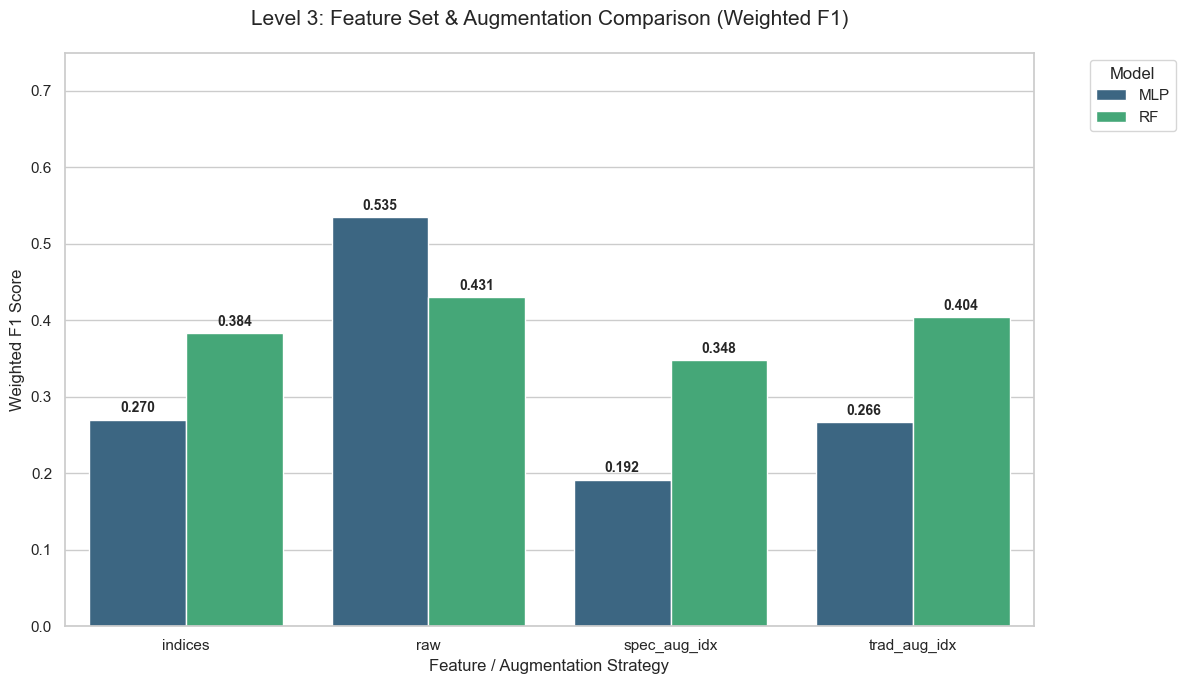

In [36]:
# Level 3 comparison with labels
df_l3 = df_results[df_results['Level'] == 3].copy()

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_l3, x='Features', y='F1_w', hue='Model', palette='viridis')

# Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')

plt.title('Level 3: Feature Set & Augmentation Comparison (Weighted F1)', fontsize=15, pad=20)
plt.ylabel('Weighted F1 Score', fontsize=12)
plt.xlabel('Feature / Augmentation Strategy', fontsize=12)
plt.ylim(0, 0.75) # Extra space for labels
plt.xticks(rotation=0)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

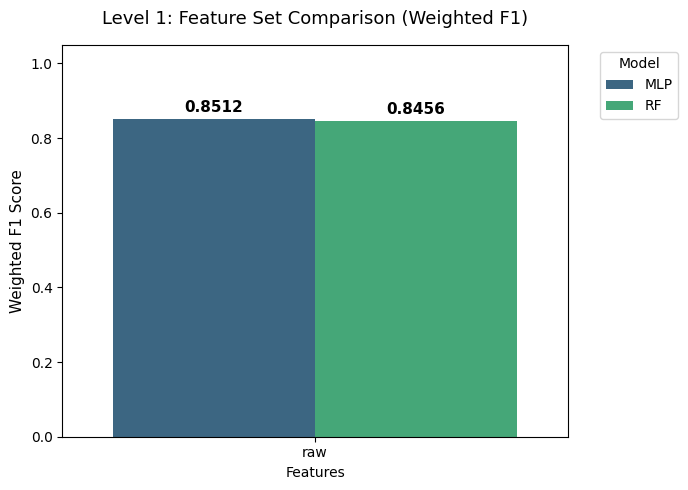

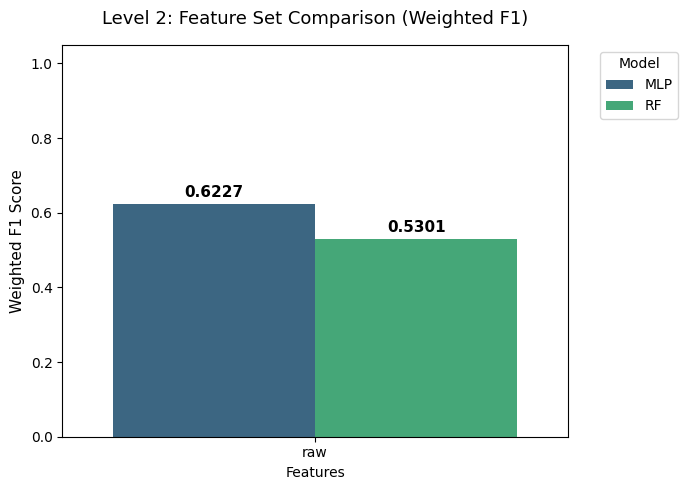

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_l12 = pd.DataFrame([
    {'Level': 1, 'Features': 'raw', 'Model': 'MLP', 'F1_w': 0.8512},
    {'Level': 1, 'Features': 'raw', 'Model': 'RF',  'F1_w': 0.8456},
    {'Level': 2, 'Features': 'raw', 'Model': 'MLP', 'F1_w': 0.6227},
    {'Level': 2, 'Features': 'raw', 'Model': 'RF',  'F1_w': 0.5301},
])

for lvl in [1, 2]:
    df = df_l12[df_l12['Level'] == lvl]
    plt.figure(figsize=(7, 5))
    ax = sns.barplot(data=df, x='Features', y='F1_w', hue='Model', palette='viridis')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')
    plt.title(f'Level {lvl}: Feature Set Comparison (Weighted F1)', fontsize=13, pad=15)
    plt.ylabel('Weighted F1 Score', fontsize=11)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

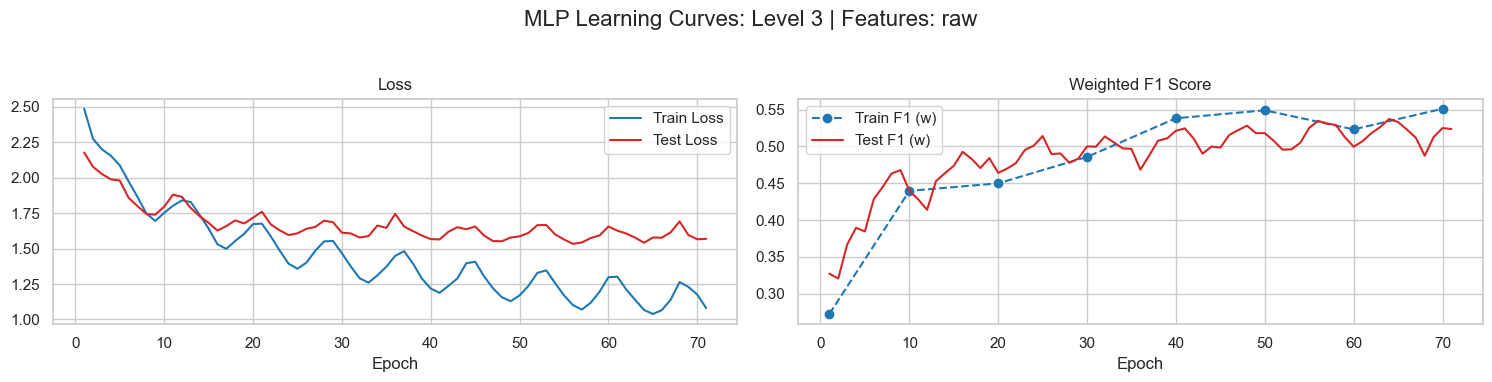

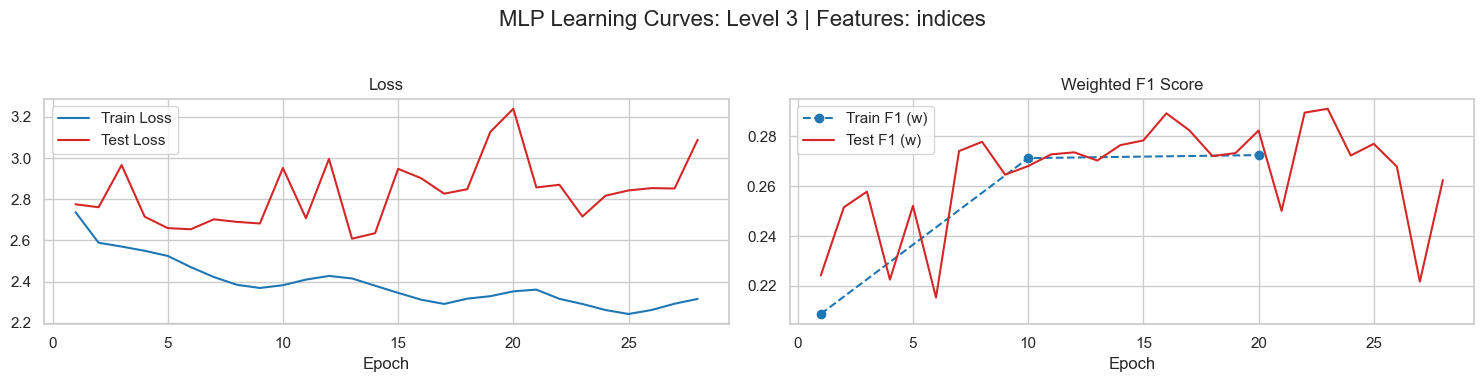

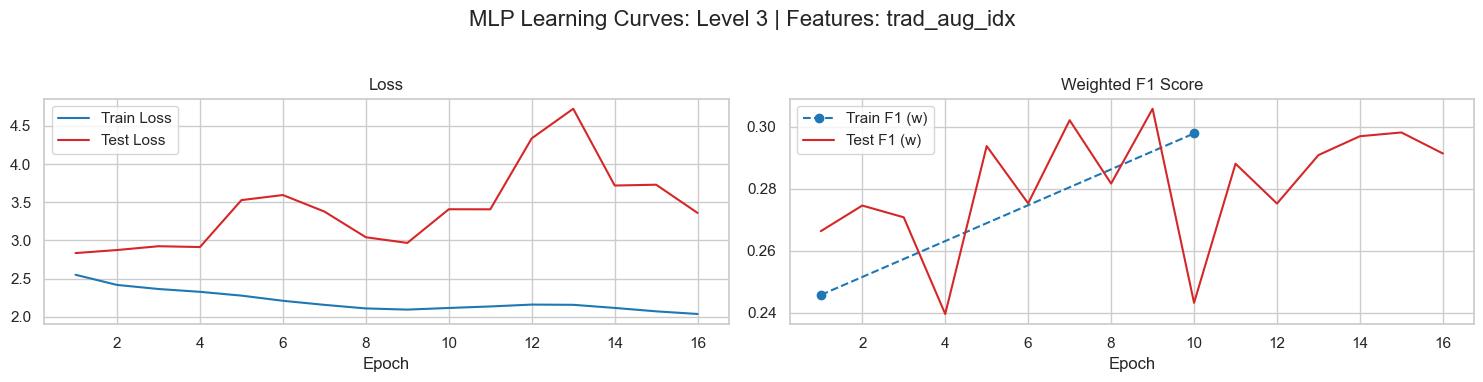

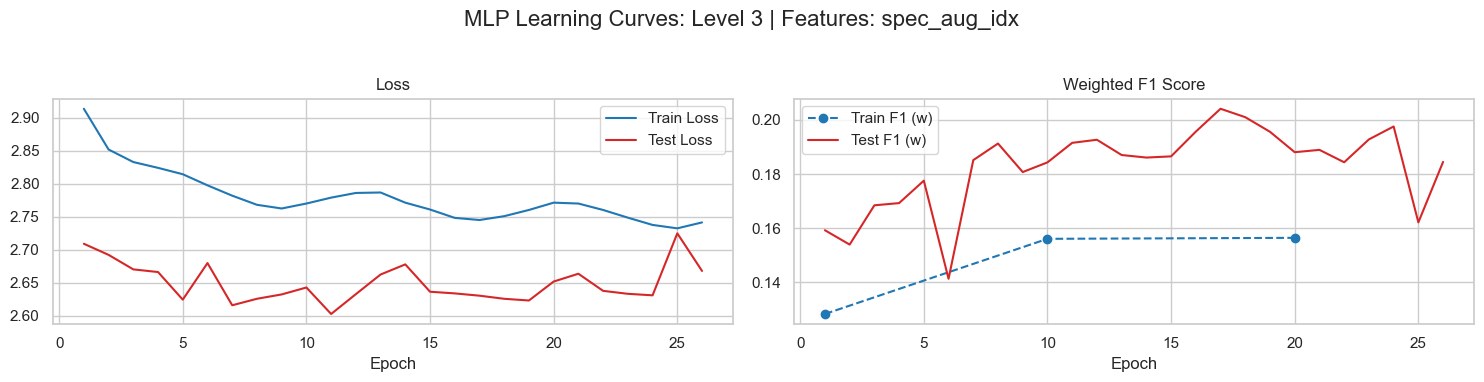

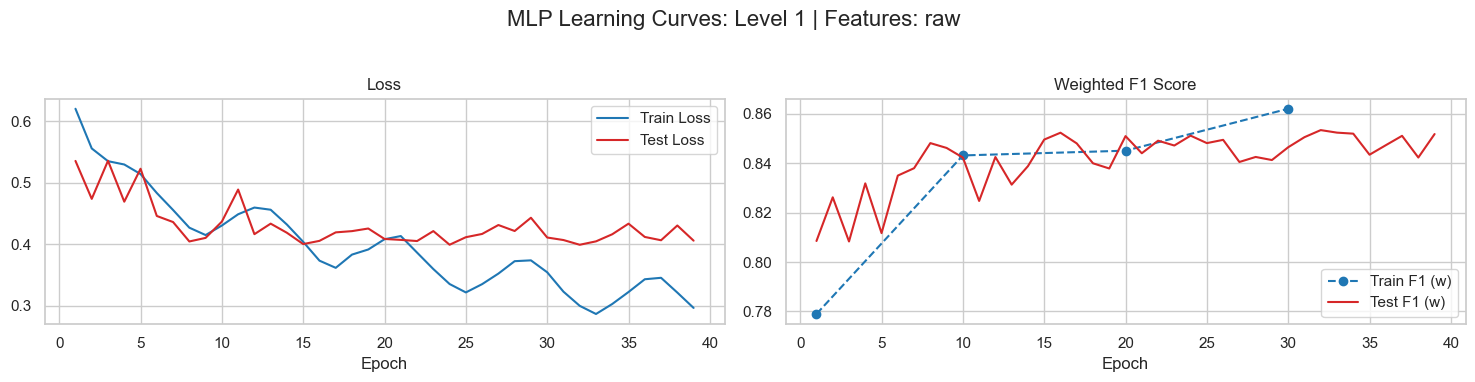

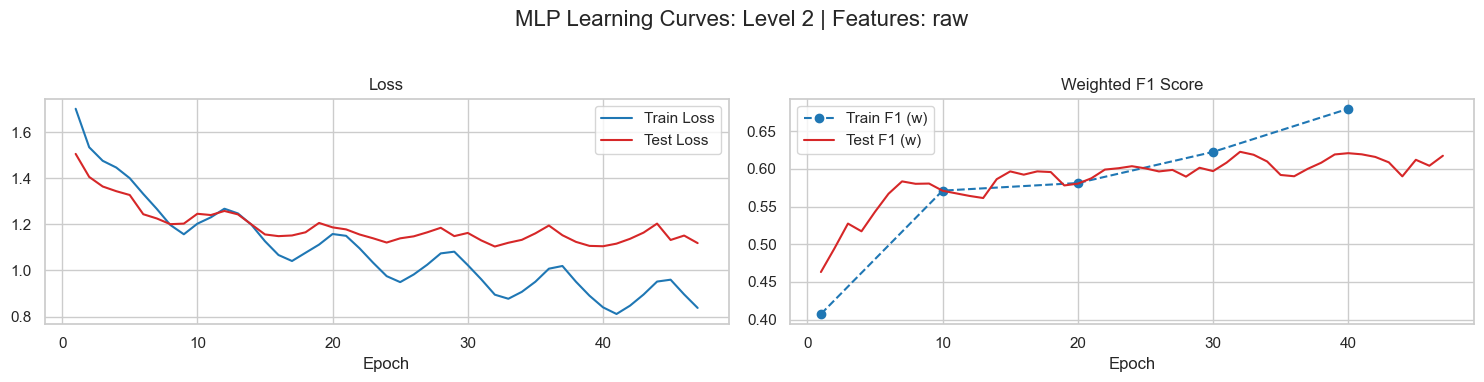

In [34]:
# Iterate through all trained MLP models
for (lvl, fs), hist in all_histories.items():
    epochs = range(1, len(hist['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f'MLP Learning Curves: Level {lvl} | Features: {fs}', fontsize=16)

    # Plot 1: Loss
    ax1.plot(epochs, hist['train_loss'], label='Train Loss', color='#1f77b4')
    ax1.plot(epochs, hist['test_loss'], label='Test Loss', color='#d62728')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    # Plot 2: F1 Score
    # Filter out None values for Train F1 (since it's logged every 10 epochs)
    train_f1_x = [i for i, f1 in enumerate(hist['train_f1_weighted'], 1) if f1 is not None]
    train_f1_y = [f1 for f1 in hist['train_f1_weighted'] if f1 is not None]

    ax2.plot(train_f1_x, train_f1_y, label='Train F1 (w)', marker='o', linestyle='--', color='#1f77b4')
    ax2.plot(epochs, hist['f1_weighted'], label='Test F1 (w)', color='#d62728')
    ax2.set_title('Weighted F1 Score')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

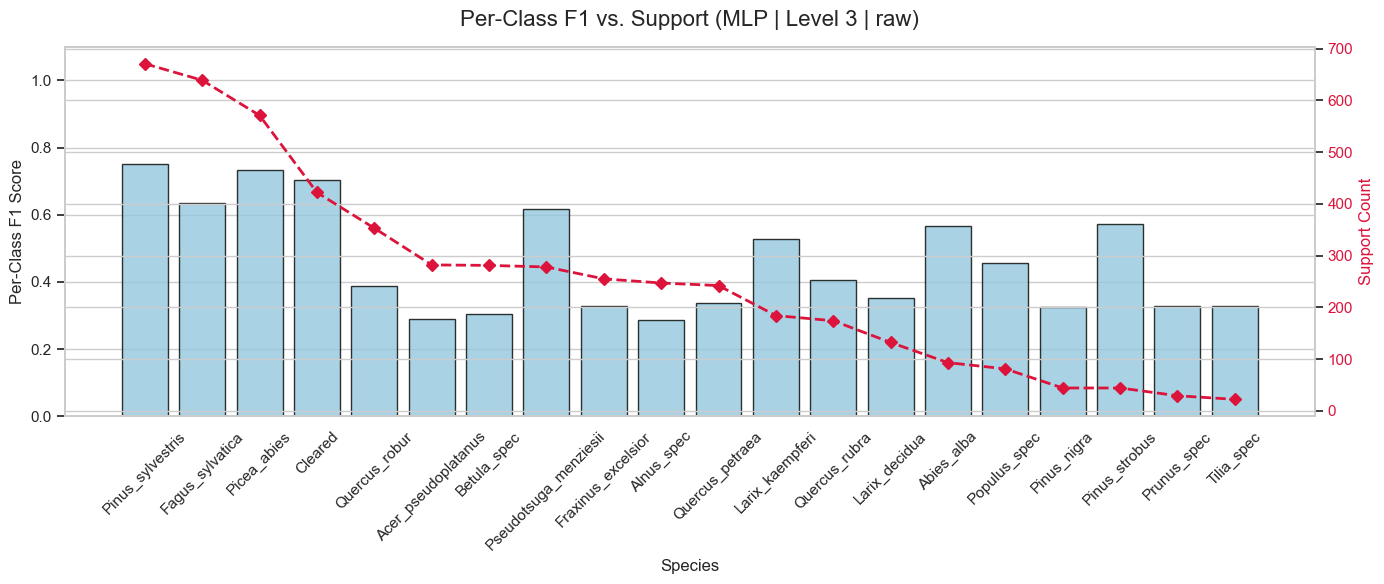

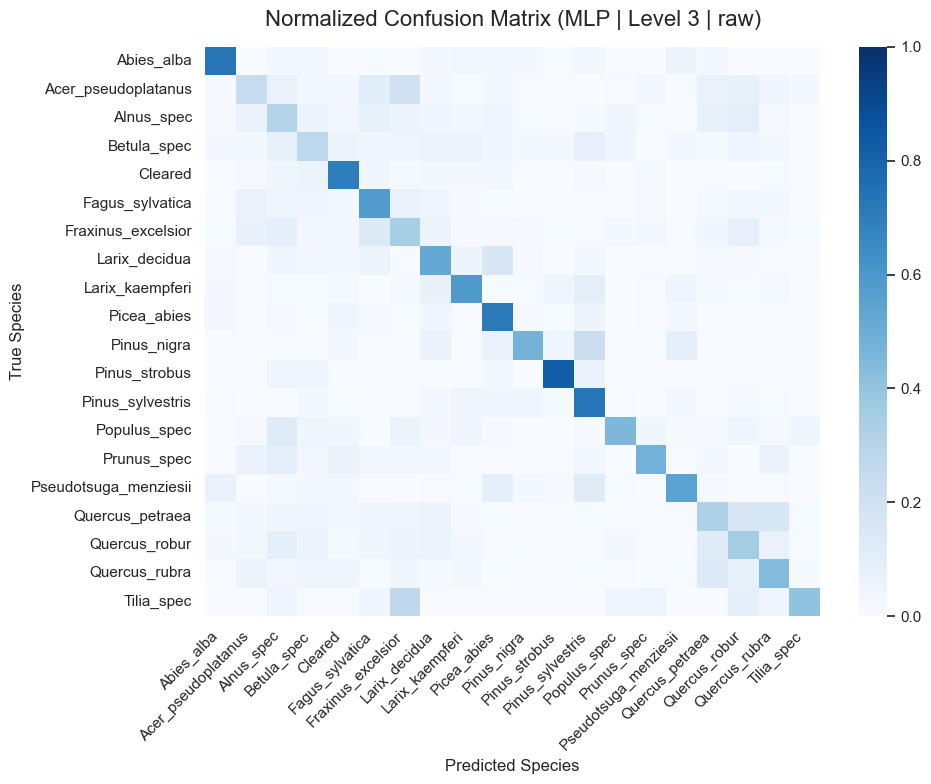

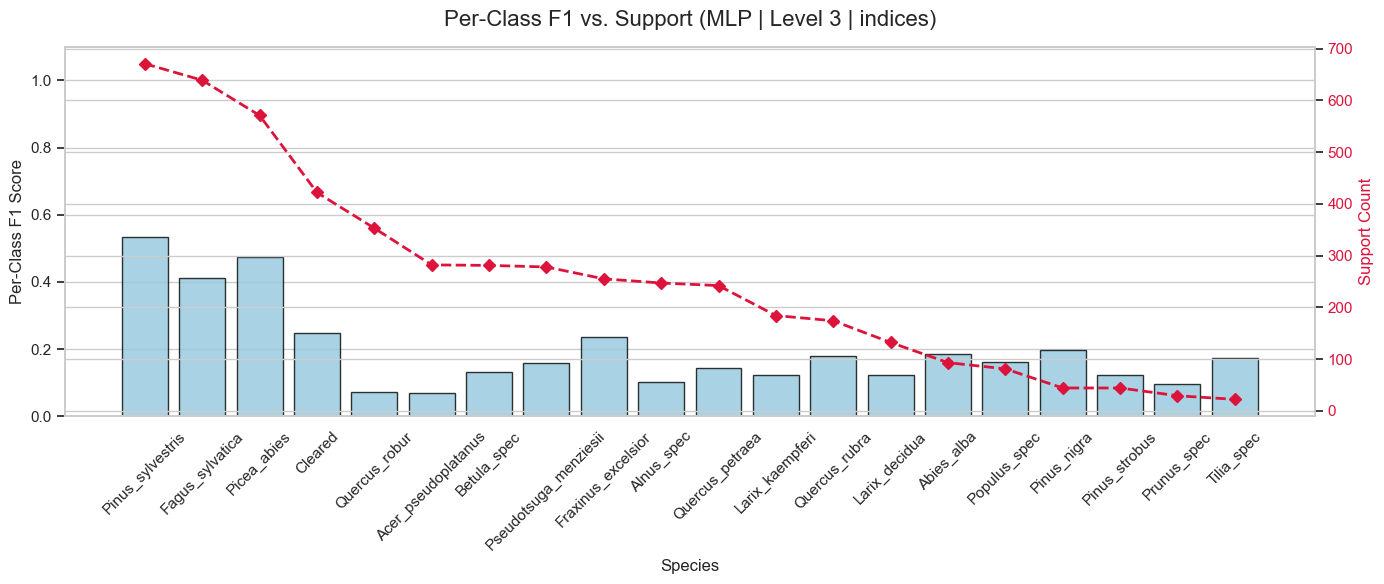

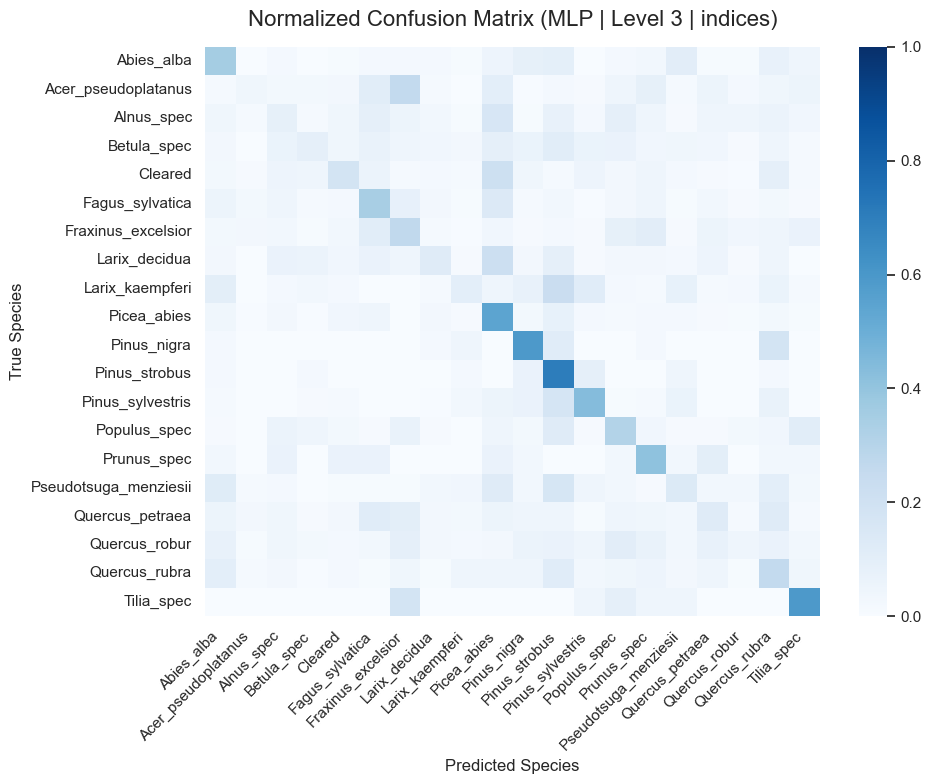

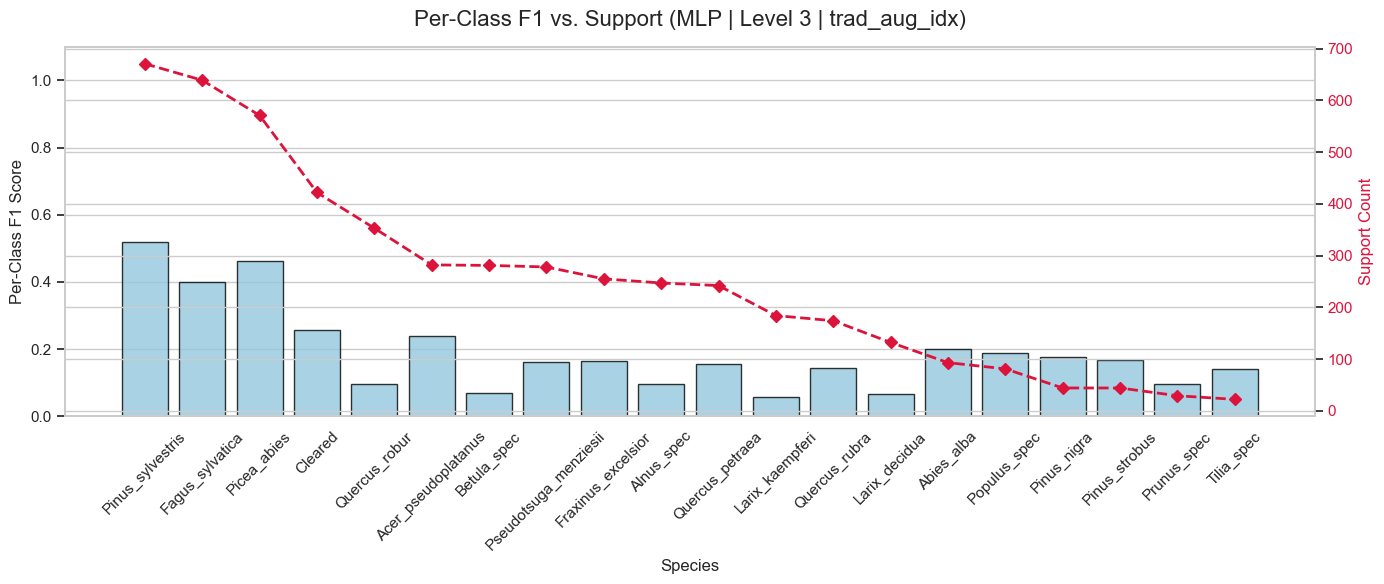

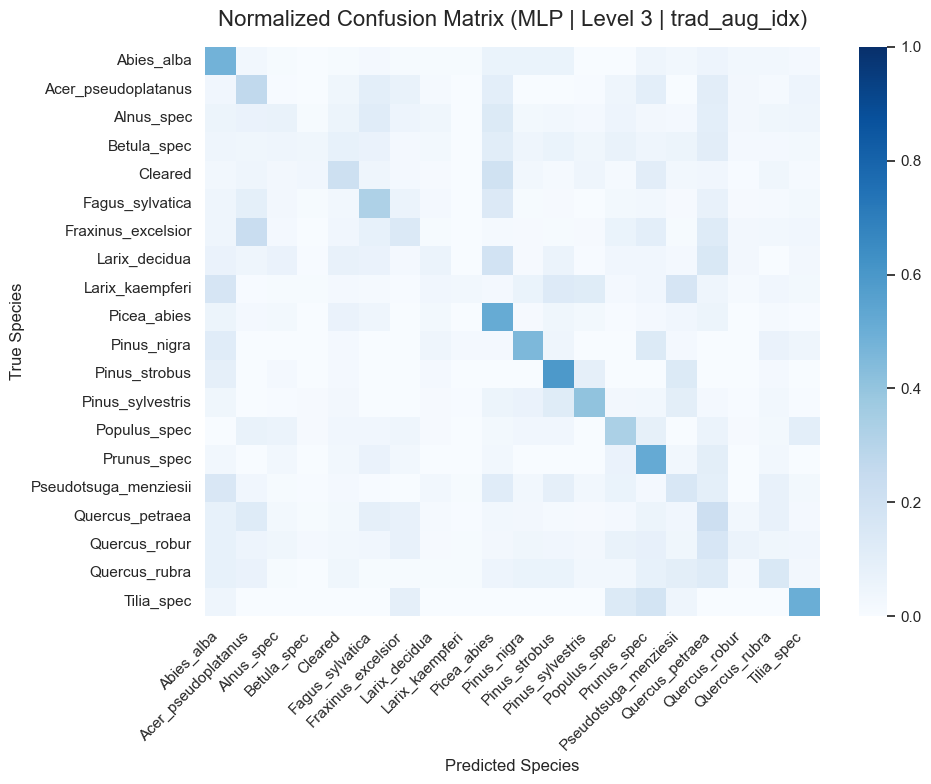

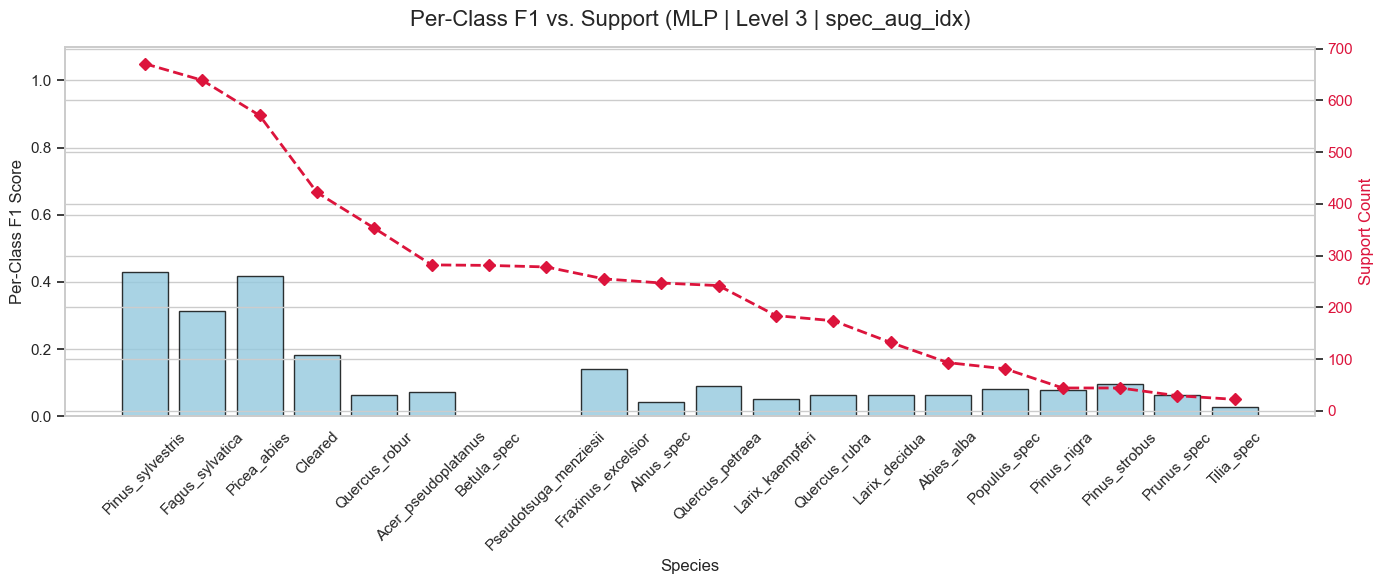

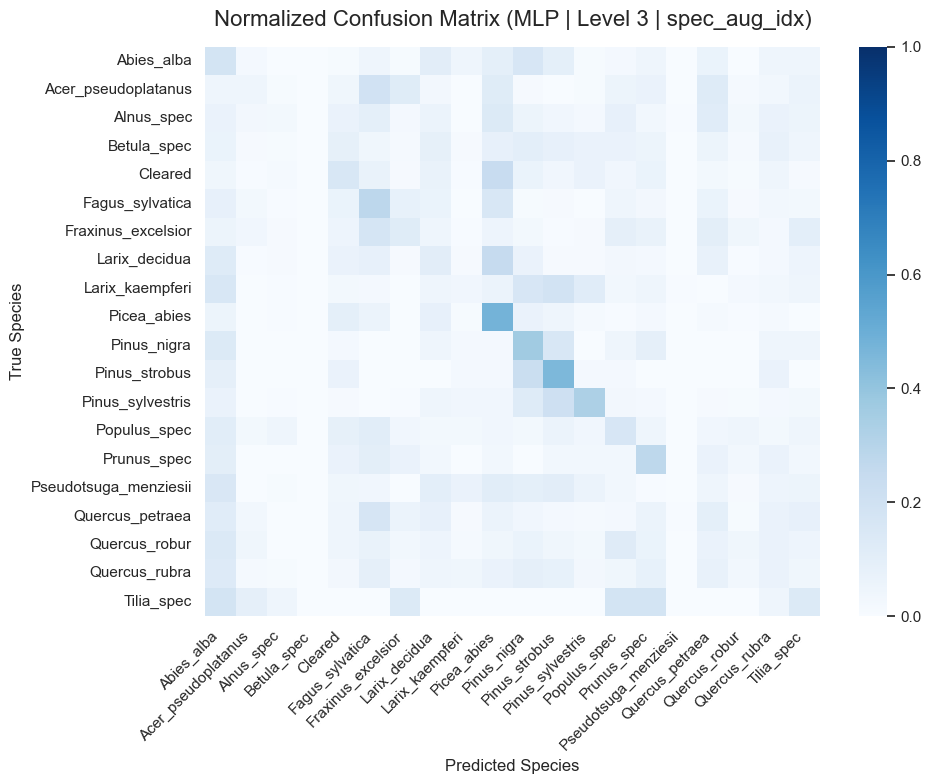

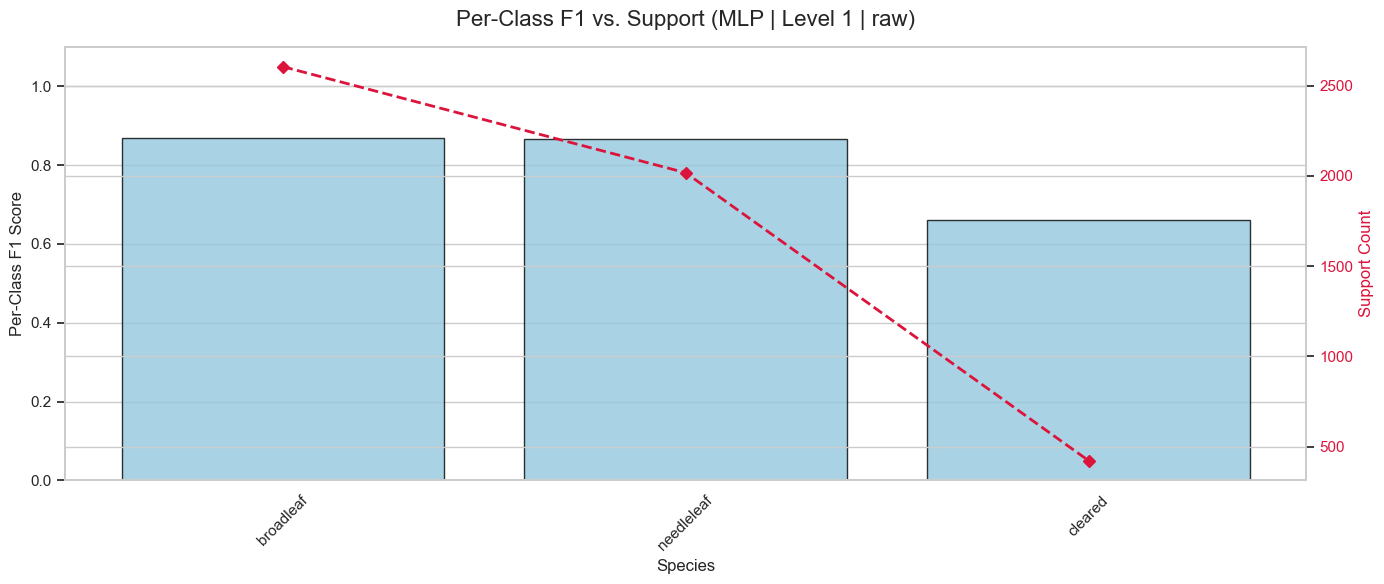

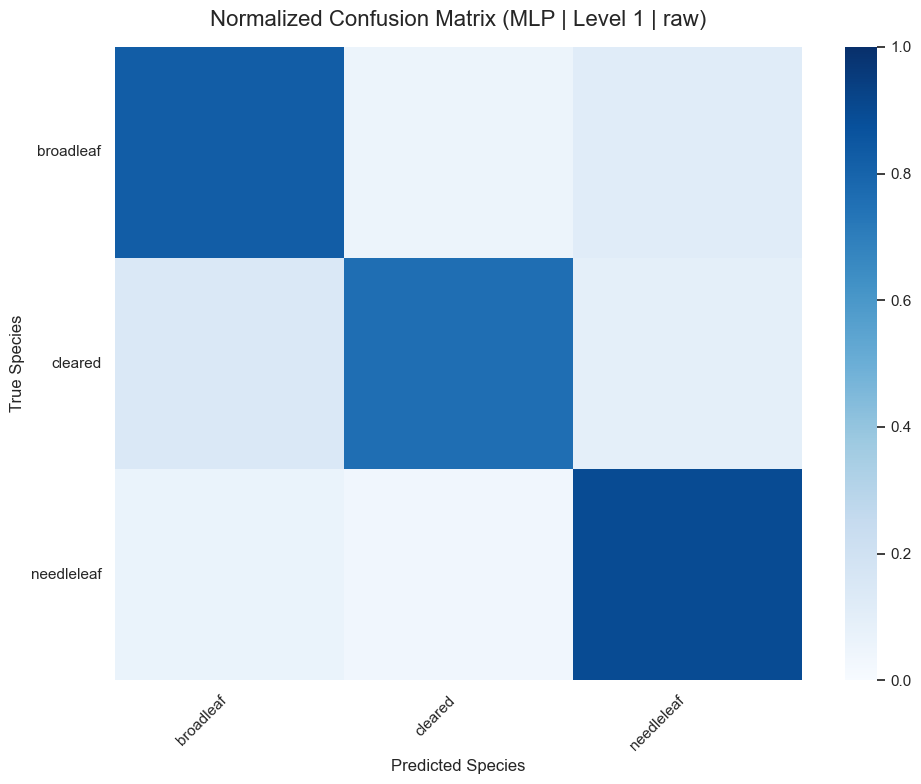

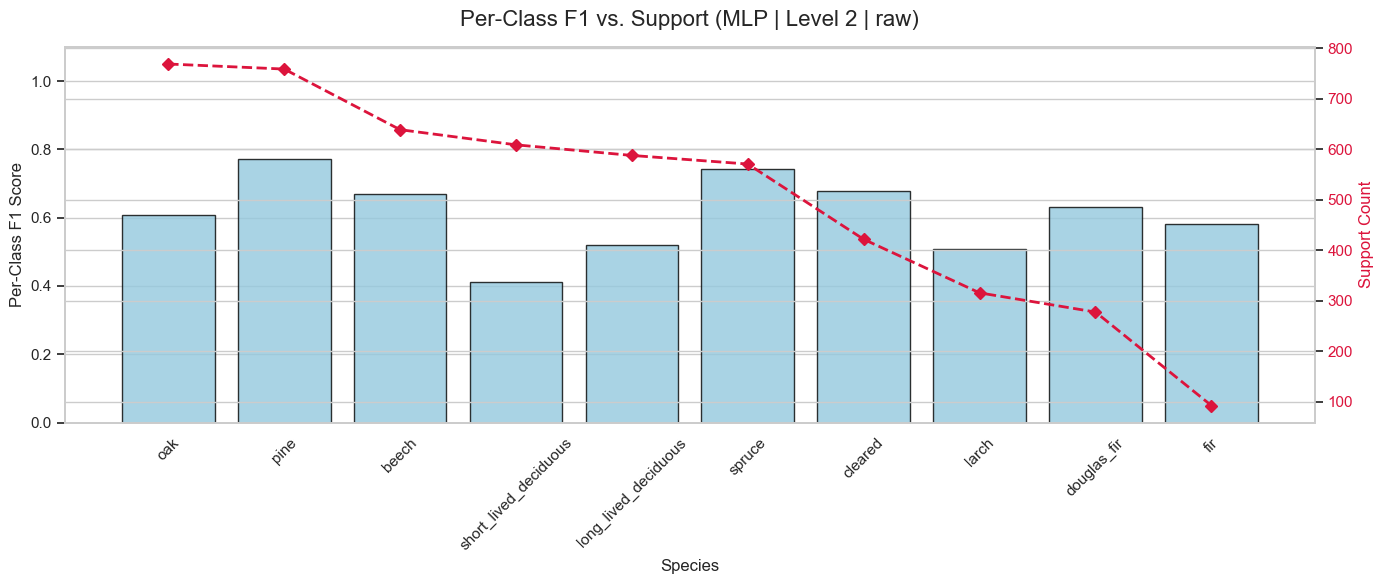

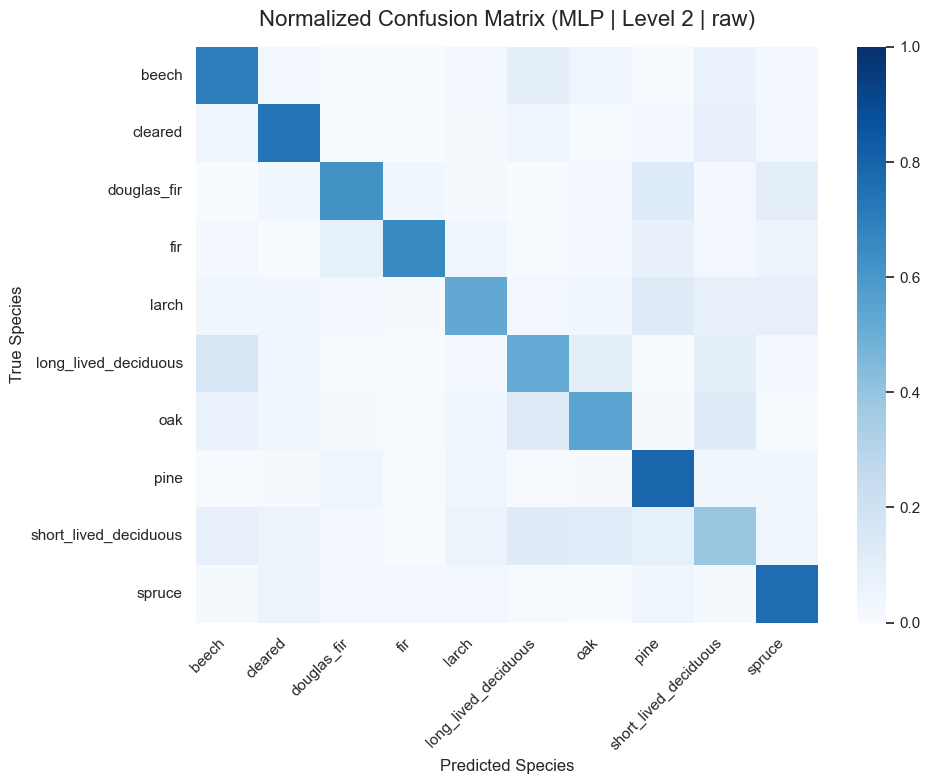

In [39]:
import collections
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through all unique models in all_results
for (lvl, fs, model_type) in all_results.keys():
    
    # 1. Extract Data based on model type
    if model_type == 'MLP':
        data_src = all_histories[(lvl, fs)]
        y_true = data_src['y_true_final']
        y_pred = data_src['y_pred_final']
        per_class_f1 = data_src['per_class_f1']
    else:
        # Assuming RF results are stored in all_results dict
        data_src = all_results[(lvl, fs, 'RF')]
        if 'y_true' not in data_src: continue # Skip if RF doesn't have class data
        y_true = data_src['y_true']
        y_pred = data_src['y_pred']
        per_class_f1 = data_src['per_class_f1']
    
    classes = LEVELS[lvl]['classes']
    
    # --- Data Prep for Class Imbalance ---
    class_counts = collections.Counter(y_true)
    support = [class_counts[i] for i in range(len(classes))]
    df_plot = pd.DataFrame({
        'Species': classes, 
        'F1': per_class_f1, 
        'Support': support
    }).sort_values('Support', ascending=False)

    # ==========================================
    # VISUALIZATION A: Class Imbalance (Separate)
    # ==========================================
    fig_imbal, ax_imbal = plt.subplots(figsize=(14, 6))
    
    # Plot Imbalance Bar
    sns.barplot(data=df_plot, x='Species', y='F1', color='skyblue', ax=ax_imbal, alpha=0.8, edgecolor='black')
    ax_imbal.set_title(f'Per-Class F1 vs. Support ({model_type} | Level {lvl} | {fs})', fontsize=16, pad=15)
    ax_imbal.tick_params(axis='x', rotation=45)
    ax_imbal.set_ylabel('Per-Class F1 Score', fontsize=12)
    ax_imbal.set_ylim(0, 1.1)
    
    # Plot Support Line
    ax_supp = ax_imbal.twinx()
    ax_supp.plot(df_plot['Species'], df_plot['Support'], color='crimson', marker='D', linestyle='--', linewidth=2)
    ax_supp.set_ylabel('Support Count', color='crimson', fontsize=12)
    ax_supp.tick_params(axis='y', labelcolor='crimson')
    
    plt.tight_layout()
    plt.show()

    # ==========================================
    # VISUALIZATION B: Confusion Matrix (Separate)
    # ==========================================
    # Calculate and normalize matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Ignore zero-division warnings, then replace NaNs with 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_norm = np.nan_to_num(cm_norm)
    
    plt.figure(figsize=(10, 8)) # Give the matrix a nice square-ish aspect ratio
    sns.heatmap(cm_norm, annot=False, cmap='Blues', xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)
    
    plt.title(f'Normalized Confusion Matrix ({model_type} | Level {lvl} | {fs})', fontsize=16, pad=15)
    plt.xlabel('Predicted Species', fontsize=12)
    plt.ylabel('True Species', fontsize=12)
    
    # Rotate labels so they don't overlap
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

---
## 11  Spectral Signature Boxplots

One figure per categorie.  
Each figure shows the distribution of the 12 Sentinel-2 band values across all training patches for that category.  
Bands: B1 B2 B3 B4 B5 B6 B7 B8 B8A B9 B11 B12.

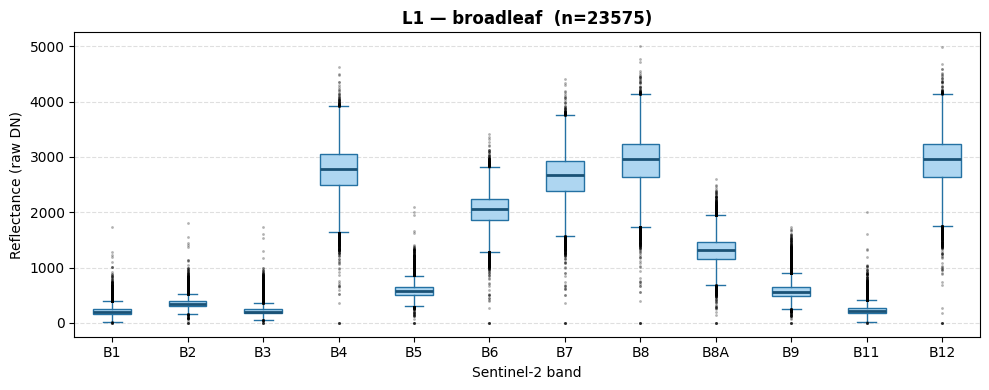

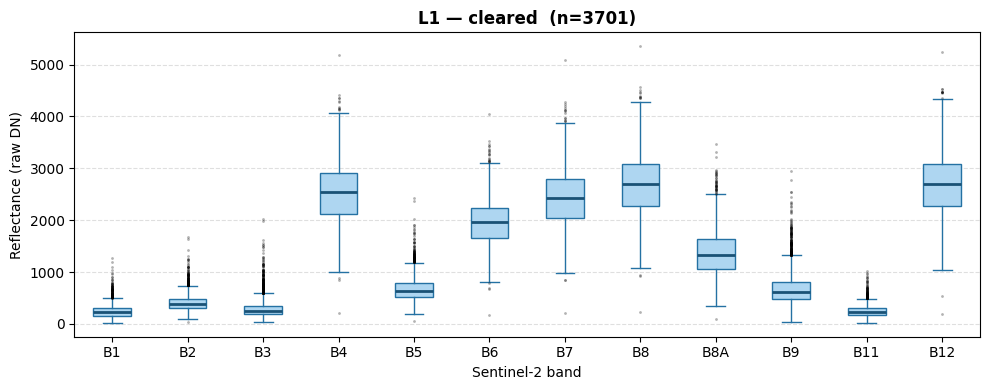

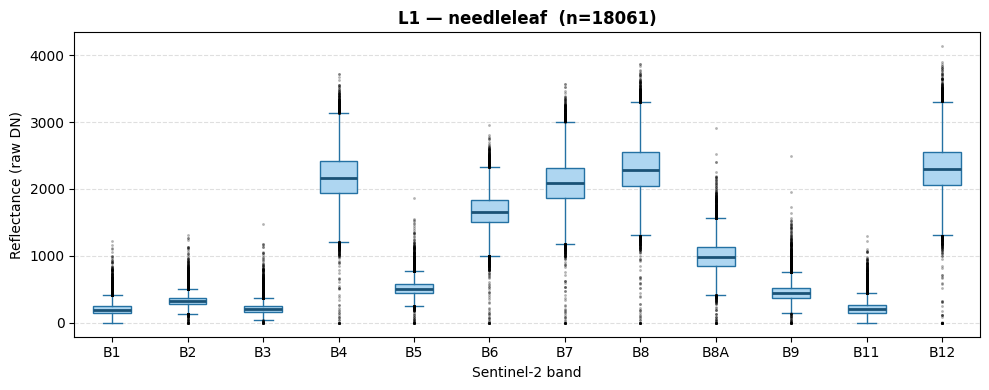

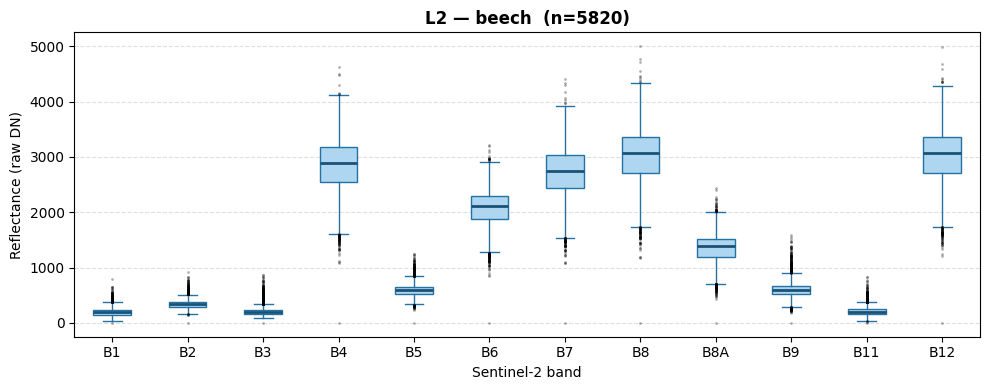

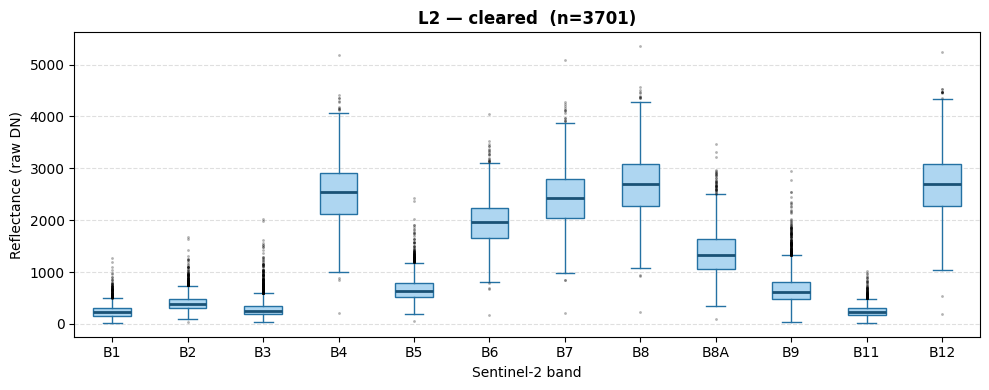

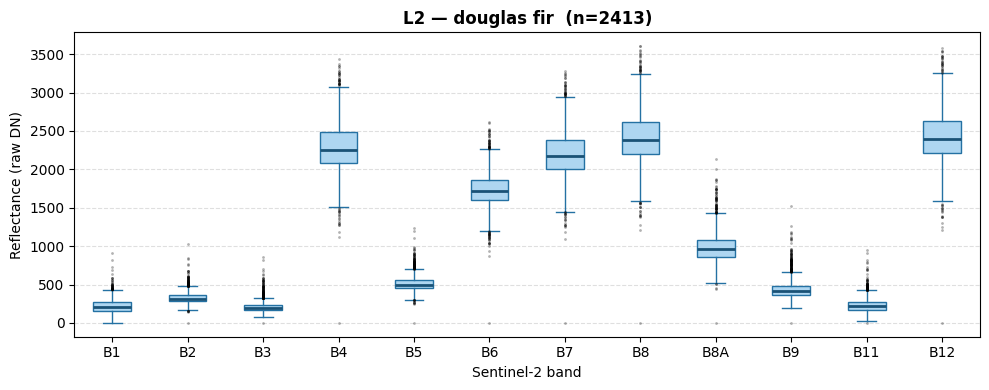

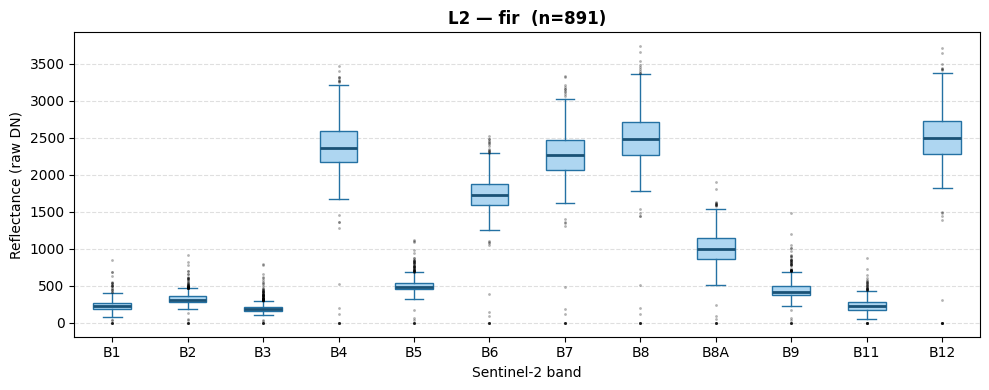

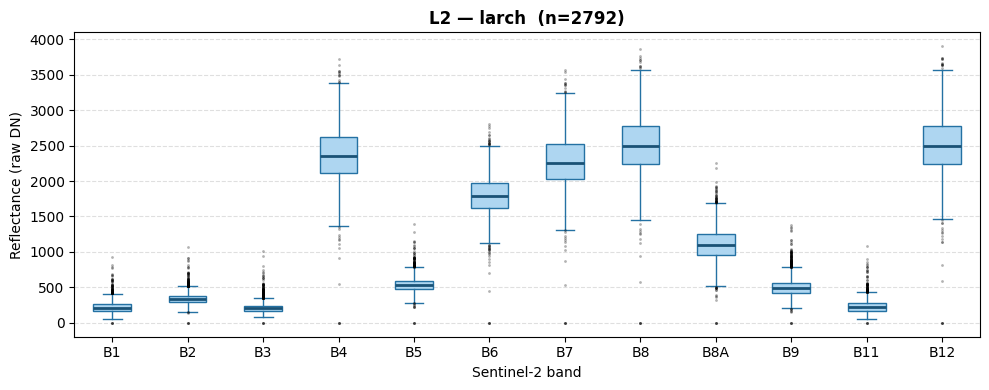

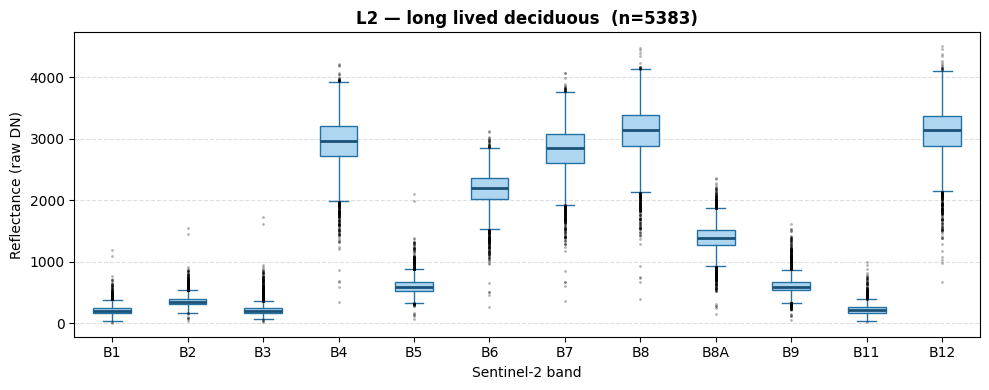

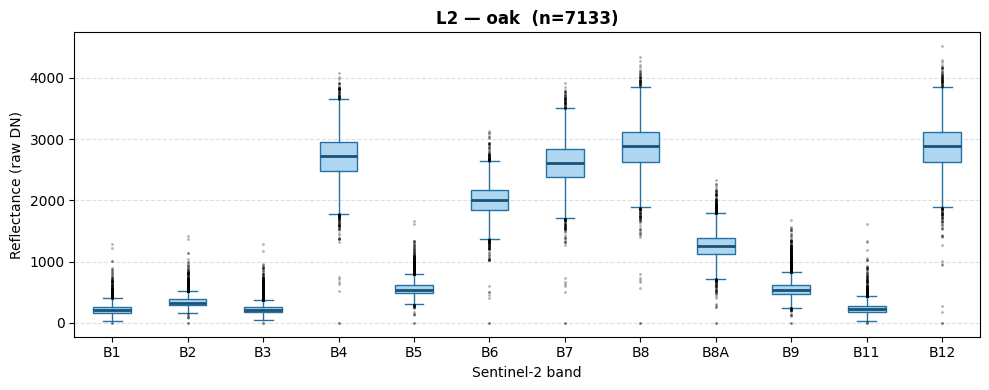

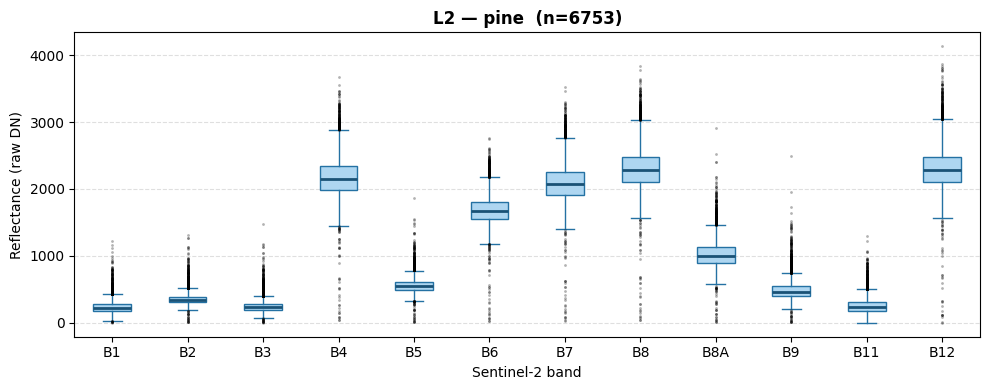

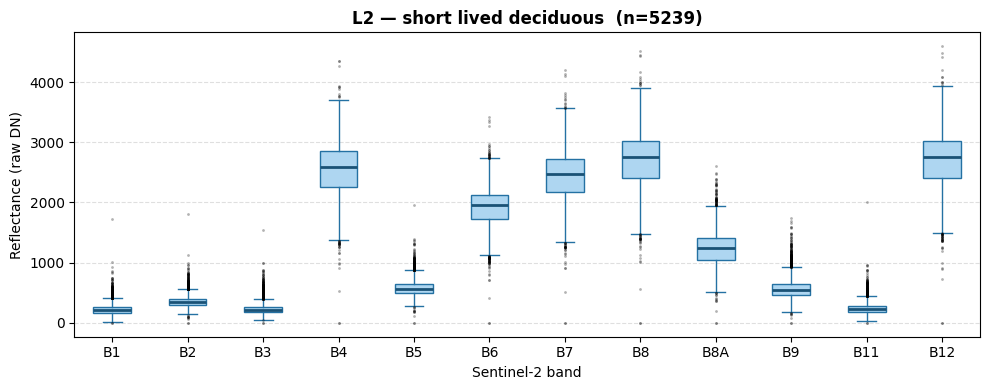

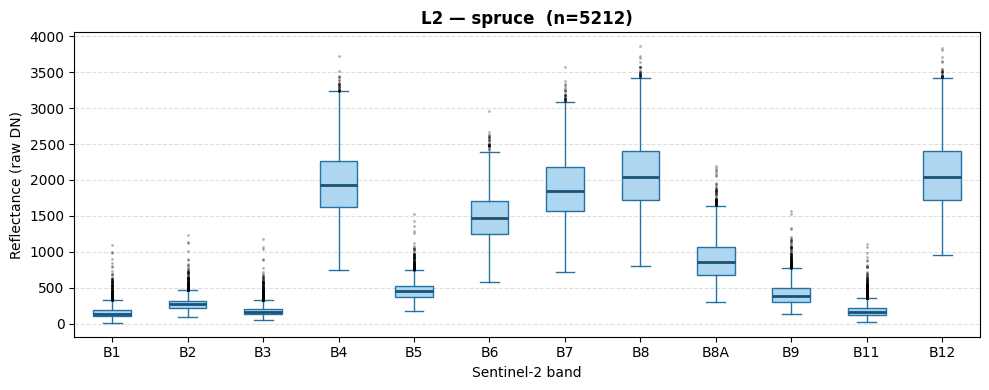

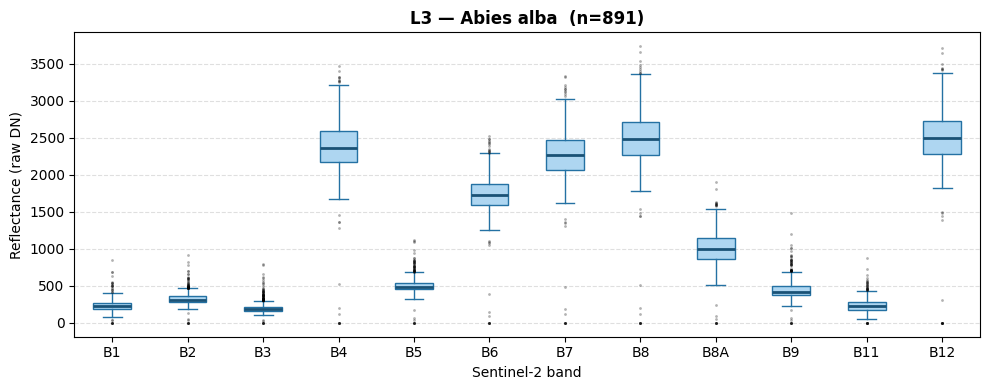

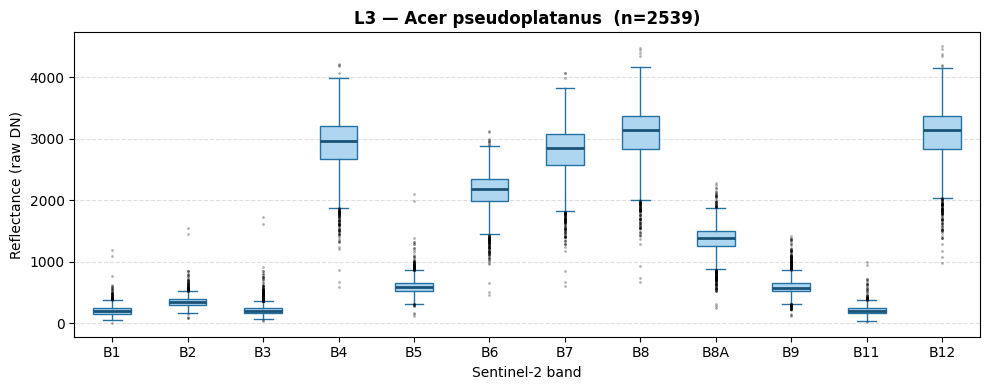

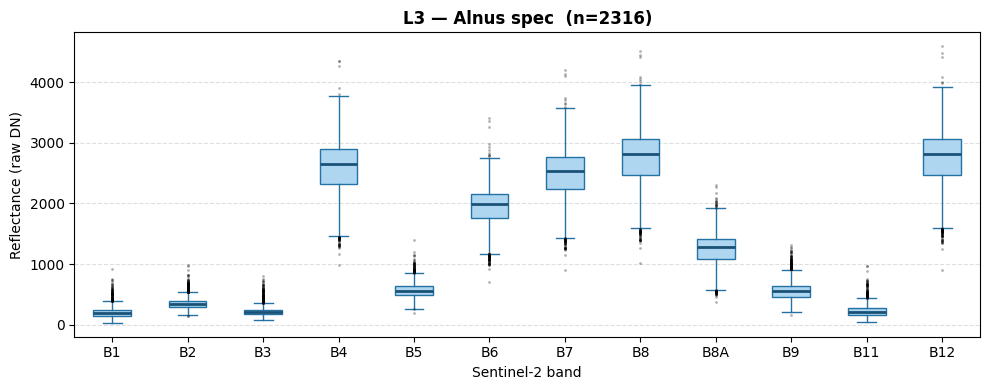

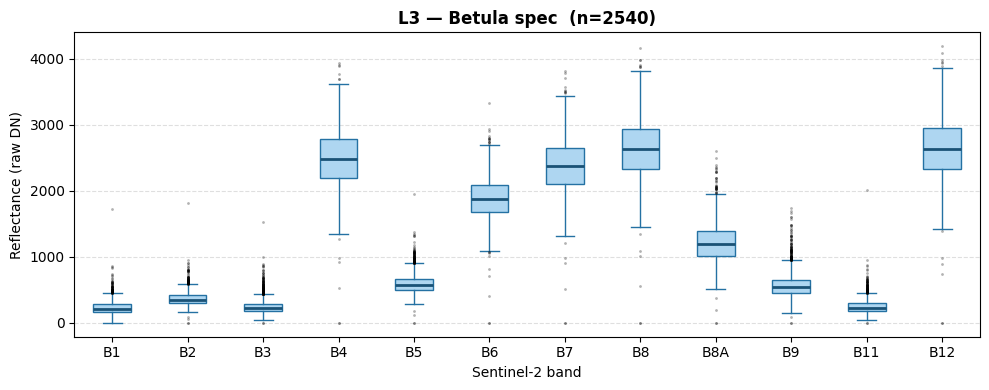

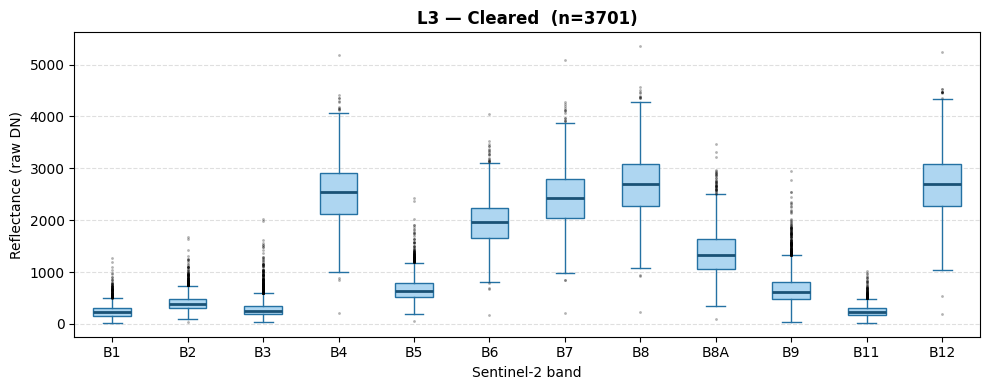

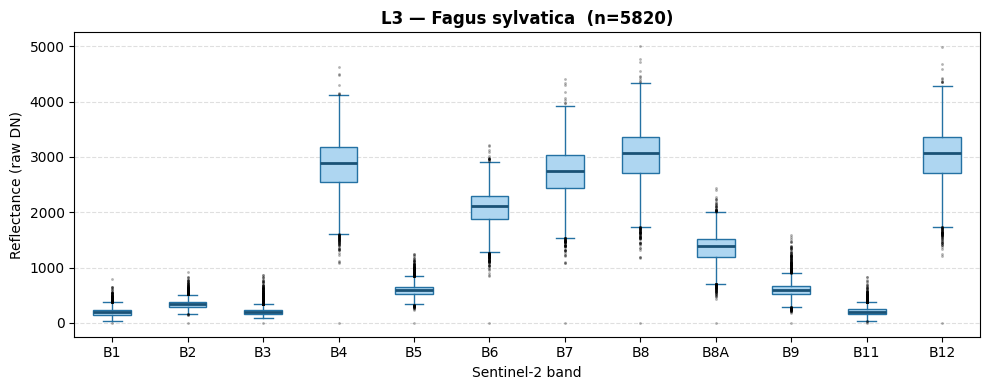

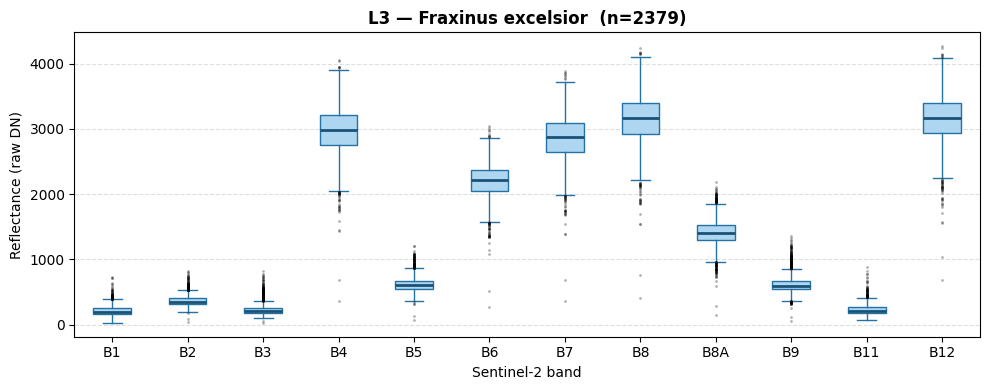

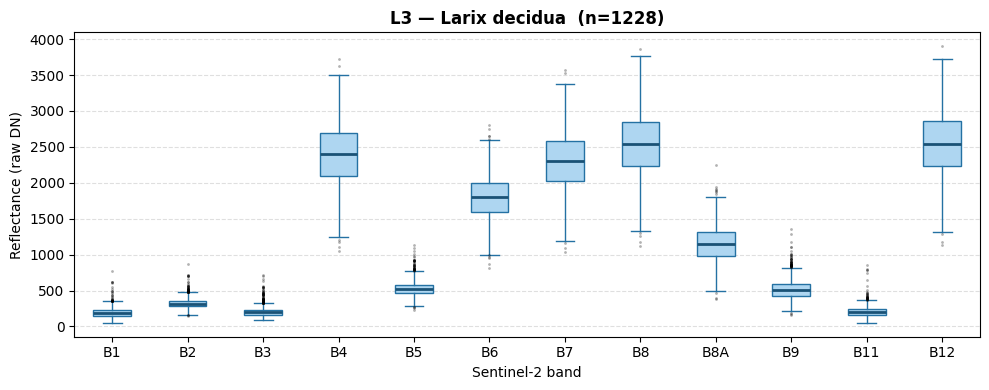

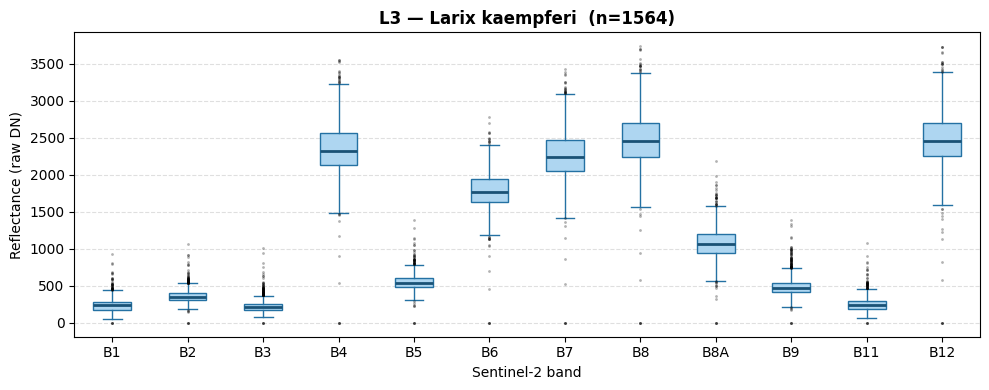

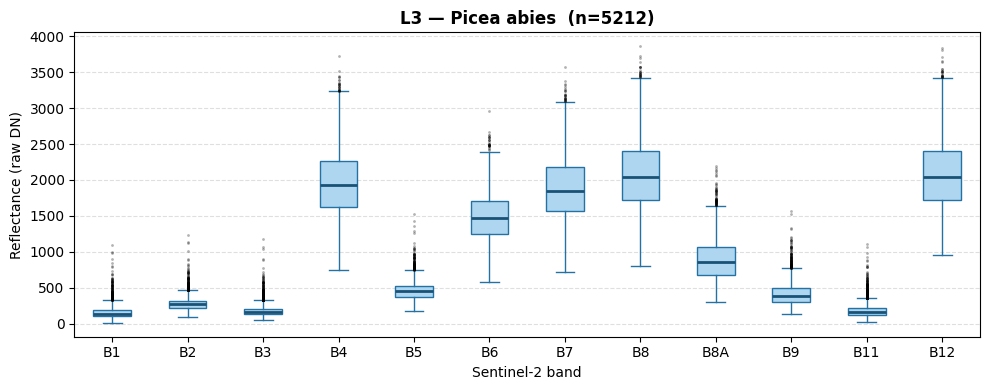

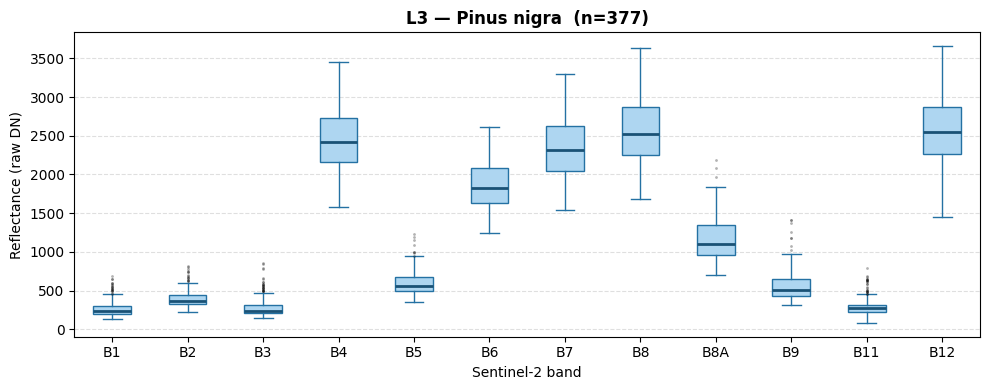

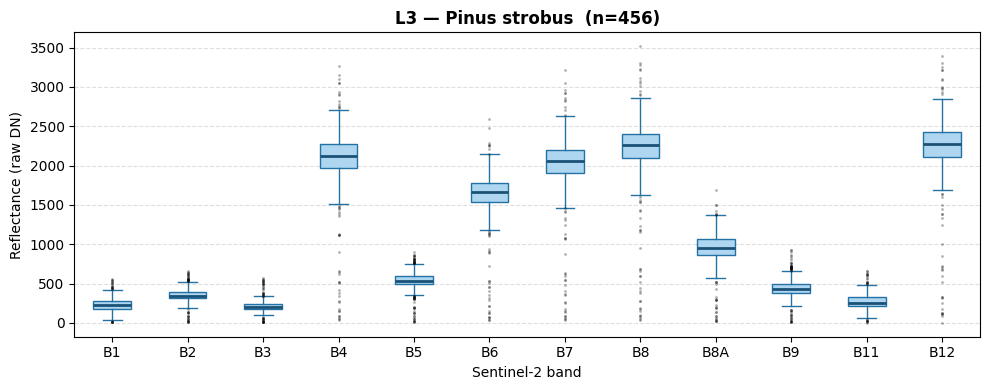

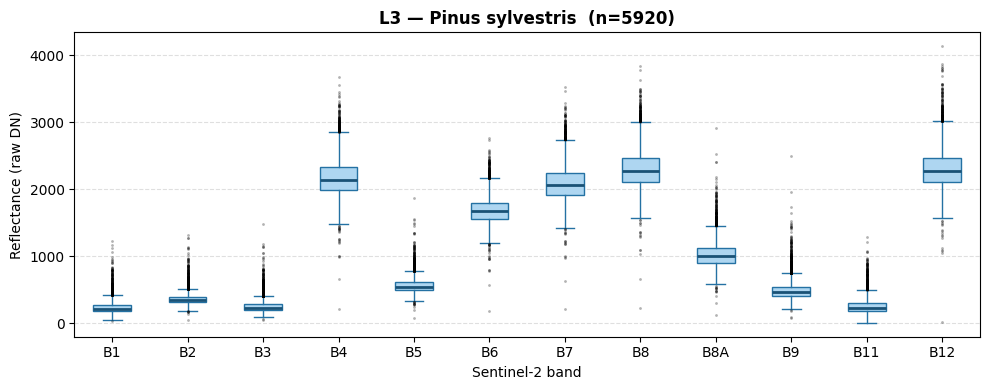

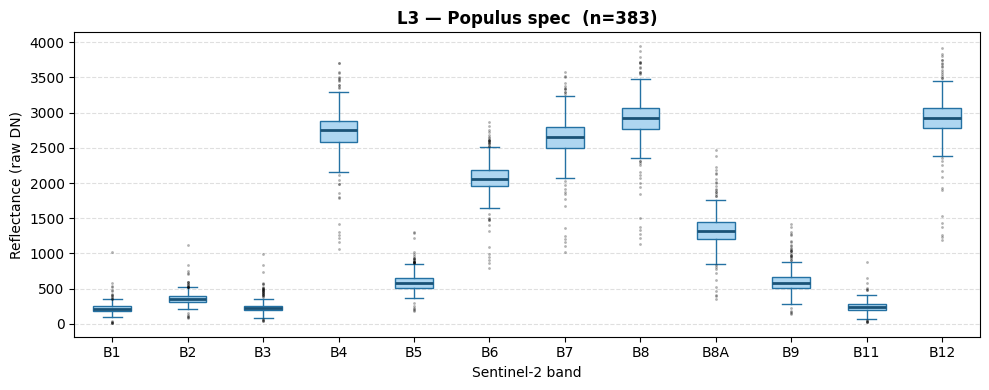

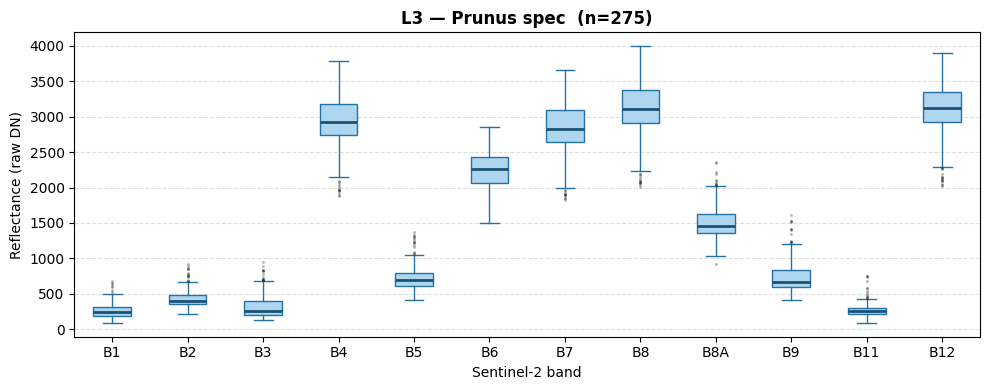

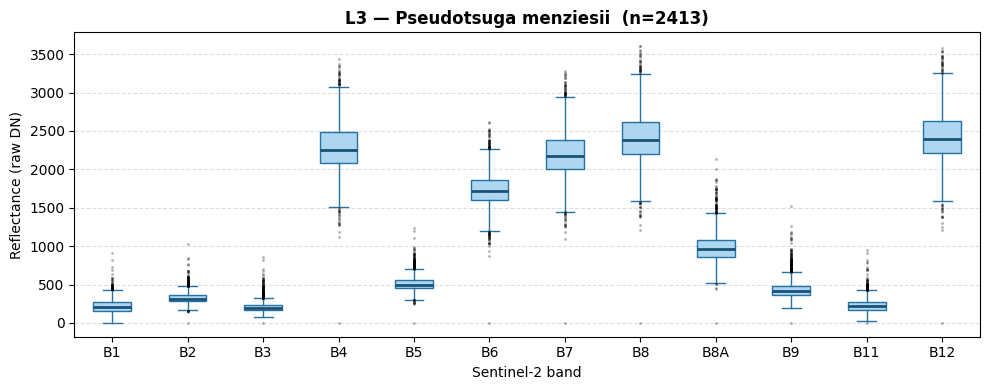

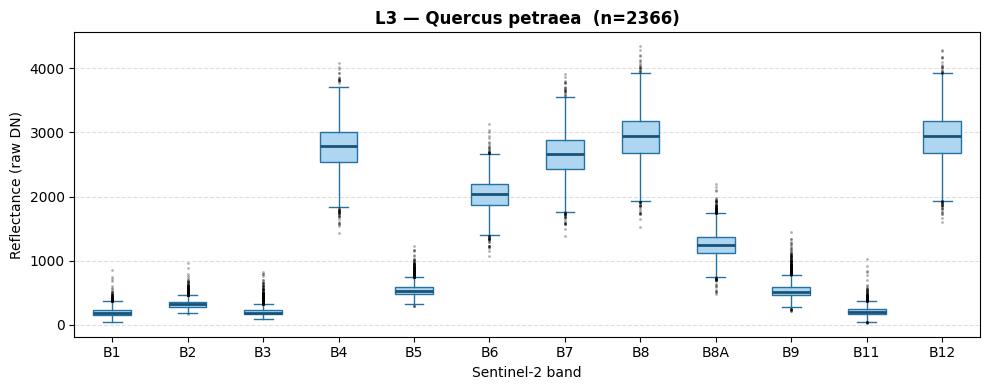

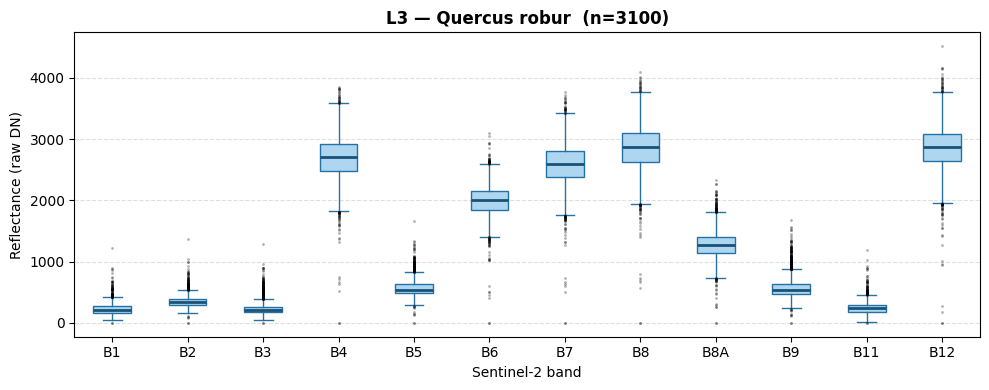

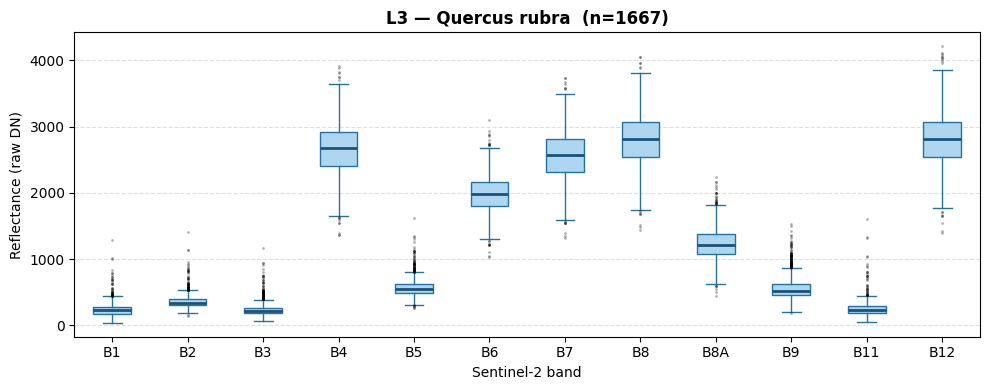

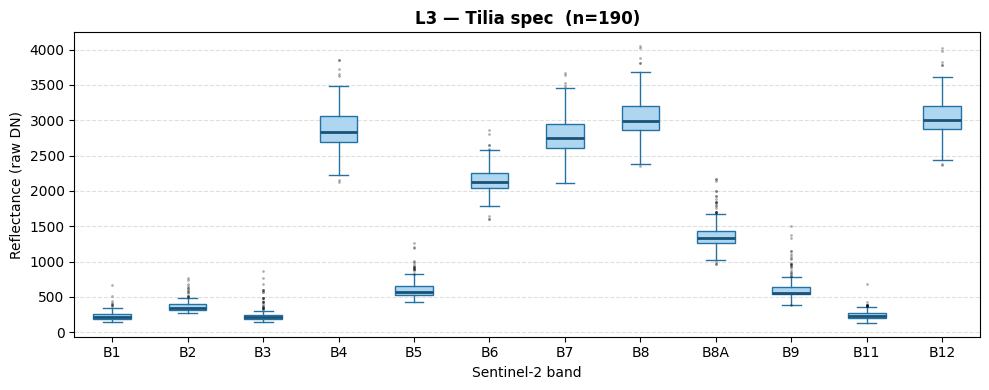

Done — figures saved for all levels.


In [10]:
# ── 11  Spectral signature boxplots — all levels ─────────────────────────────
BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
N_BANDS    = 12
PATCH_PIX  = MAX_H * MAX_W  # 441

X_bands = X_raw_train.reshape(-1, N_BANDS, PATCH_PIX).mean(axis=2)  # (N, 12)

LEVEL_CONFIGS = [
    (1, LEVEL1_MAP),
    (2, LEVEL2_MAP),
    (3, None),          # Level 3 uses species_list directly
]

for lvl, lmap in LEVEL_CONFIGS:
    if lmap is not None:
        y_lv, class_names = build_level_labels(y_l3_train, lmap)
    else:
        y_lv       = y_l3_train
        class_names = species_list

    for cls_idx, cls_name in enumerate(class_names):
        mask = y_lv == cls_idx
        data = X_bands[mask]
        n    = mask.sum()

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.boxplot(
            [data[:, b] for b in range(N_BANDS)],
            labels=BAND_NAMES,
            patch_artist=True,
            boxprops=dict(facecolor='#AED6F1', color='#2471A3'),
            medianprops=dict(color='#1A5276', linewidth=2),
            whiskerprops=dict(color='#2471A3'),
            capprops=dict(color='#2471A3'),
            flierprops=dict(marker='.', markersize=2, alpha=0.3, color='grey'),
        )
        ax.set_title(f'L{lvl} — {cls_name.replace("_", " ")}  (n={n})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Sentinel-2 band', fontsize=10)
        ax.set_ylabel('Reflectance (raw DN)', fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        fname = f'spectral_L{lvl}_{cls_idx:02d}_{cls_name}.png'
        plt.savefig(fname, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

print('Done — figures saved for all levels.')